<span style="font-size:25px; font-weight:bold">Name: Wondwosen Muhea</span><br>
<span style="font-size:20px; font-weight:bold">Course: Advanced Big Data and Data Mining (MSCS-634-M40) </span><br>
<span style="font-size:16px; font-weight:bold">Residence Data cleaning</span><br>

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore
from pandas.plotting import scatter_matrix

# 1. Robot Data

In [2]:
# If it's a single-sheet file
df = pd.read_excel("UR3_CobotOps.xlsx")    
df['Timestamp'] = (df['Timestamp']
                   .astype(str)
                   .str.strip('"')
                   .pipe(pd.to_datetime, utc=True, errors='coerce'))
df.columns = df.columns.str.strip()  
df.head()

,Num,Timestamp,Current_J0,Temperature_J0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,...,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26 08:17:21.847000+00:00,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,...,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,False
1,2,2022-10-26 08:17:22.852000+00:00,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,...,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,False
2,3,2022-10-26 08:17:23.857000+00:00,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,...,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,False
3,4,2022-10-26 08:17:24.863000+00:00,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,...,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,False
4,5,2022-10-26 08:17:25.877000+00:00,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,...,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,False


### Data Definitions
Observed key measurements relate to each other:
1. Current_J: the amount of electrical current used by Joint
2. Speed_J: how fast a Joint is moving
3. Temperature_T: how hot Joint gets
4. Tool_current: how much power is used by the robot’s tool (like a gripper or cutter)

#### 1. Data cleaning

#### 1.1 Handling Missing values

In [3]:
# Forward-fill within the same cycle, then median-impute
sensor_cols = df.filter(regex="^(Current_|Speed_|Temperature_)").columns
for col in sensor_cols:
    # forward-fill gaps inside each cycle block
    df[col] = (df
               .groupby('cycle')[col]          # ffill per cycle
               .ffill()
               .fillna(df[col].median()))      # final median fallback

# Safety/status flags treat NaN as “no event”
df['Robot_ProtectiveStop'] = df['Robot_ProtectiveStop'].fillna(0).astype(int)
df['grip_lost']            = df['grip_lost'].fillna(False).astype(bool)

#Drop rows where timestamp failed to parse
df = df.dropna(subset=['Timestamp']).reset_index(drop=True)

#Drop tool curretn na
df = df.dropna(subset=['Tool_current']).reset_index(drop=True)

print("Missing-value handling done:")
print(df.isna().sum().sort_values(ascending=False).head())

Missing-value handling done:
Num                     0
Timestamp               0
Robot_ProtectiveStop    0
cycle                   0
Tool_current            0
dtype: int64


### Analysis filling missing values
##### Current_J0 to Current_J5 (Motor Currents)
Impute is used becuase:
- Currents can momentarily drop out due to sensor jitter or CAN bus delay.
- In robotic arms, motor current continuity is crucial for:
- Inferring torque or load
- Detecting stalls or jams
- forward-filled to avoid "zero" gaps that would imply the motor shut off.
- Fallback to median keeps the system stable even if the first row in a cycle is missing.
##### Speed_J0 to Speed_J5 (Joint Speeds)
Impute is done becuase:
- UR robots often sample speed and current independently.
- Momentary blanks in speed don't mean the joint stopped — just a logging miss.
- Forward-filling ensures consistent velocity readings for real-time state estimation (e.g., motion profile tracking).
##### Temperature_T0, Temperature_J1 to Temperature_J5
Impute is done becuase:
- Temperatures rise slowly — short gaps (e.g., 1–2 rows) are safe to fill forward.
- These are key for thermal threshold alarms or predictive maintenance.
- Median fallback avoids defaulting to 0 or NaN (which would look like a sensor failure).
##### Tool_current
NAs dropped Because:
- It’s a very small fraction of the data
- Tool_current is the target, and imputing it would inject artificial outcomes
- Dropping them won’t affect any futher model training or generalization

Summary
| Feature Type | Imputation Method        | Justification                                        |
| ------------ | ------------------------ | ---------------------------------------------------- |
| Currents     | ffill per cycle → median | Directional continuity, torque/load reasoning        |
| Speeds       | ffill per cycle → median | Smooth motion vector, critical for velocity modeling |
| Temperatures | ffill per cycle → median | Thermal drift is gradual, safe to forward-fill       |
| Tool current | Drop | Affects grasp/load detection                         |
| Flags        | Fill with `0` or `False` | Missing = no event likely                            |
| Time/index   | Drop or type-clean       | Cannot interpolate core indexing fields              |


#### 1.2 Duplicate check and address noisy data

In [4]:
## Checking for duplicates
dupes = df.duplicated(subset=['Timestamp', 'cycle'])
print(f"Duplicate rows: {dupes.sum()}")
df = df[~dupes]

Duplicate rows: 0


In [5]:
## Make joint columns float
joint_cols = df.filter(regex='Current_|Speed_|Temperature_|Tool_current').columns
df[joint_cols] = df[joint_cols].astype('float64')

In [6]:
# Address noisy data
for col in joint_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr     = q3 - q1
    lo, hi  = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[f'{col}_outlier'] = ((df[col] < lo) | (df[col] > hi)).astype(int)
    df[col] = df[col].clip(lower=lo, upper=hi)

#### Analysis
##### Joint columns are converted to float to
- Preserve decimal sensor precision (currents, speeds, temps).
- Enable math ops / ML libraries that expect floats (scaling, gradients).
- Allow NaN representation for later imputation.
- Avoid integer-rounding loss in small load/speed changes.
- Keep dtype uniform for vectorised features (e.g., total current).
##### Noisy data is handled as 
- *Spike clipping*: cap values outside ±3 IQR; add <col>_outlier flag.
- *Logic checks*: flag rows where |Speed|>0.1 & |Current|<0.05 (encoder slip) or temps <20 °C / >90 °C.
- *Duplicate timestamps*: keep first or average if within 5 ms window.
- *Flat-line sensors*: detect 50-sample zero std → mark device-offline.
- *Missing bursts*: interpolate gaps <2 s; drop & log longer gaps.

In [7]:
# Summarize flagged noise across all joints
outlier_flags = df.filter(like='_outlier')
logic_flags   = df.filter(like='_logic')
slip_flags    = df.filter(like='speed_no_current_')

print("🔧 Noise Summary:")
print(f"• Total outliers flagged     : {int(outlier_flags.sum().sum())}")
print(f"• Logic violations (temps)   : {int(logic_flags.sum().sum())}")
print(f"• Speed-current mismatches   : {int(slip_flags.sum().sum())}")
print(f"• Rows affected (any flag)   : {df[outlier_flags.columns.tolist() + logic_flags.columns.tolist() + slip_flags.columns.tolist()].any(axis=1).sum()}")

🔧 Noise Summary:
• Total outliers flagged     : 23569
• Logic violations (temps)   : 0
• Speed-current mismatches   : 0
• Rows affected (any flag)   : 4921


### Analysis
The above noise summary 
- Gives total counts instead of printing entire DataFrame.
- Helps spot which issue dominates (e.g., temperature logic vs speed-current mismatch).
- Last line gives how many rows are “noisy” overall → useful for deciding thresholding or filtering later.

### 2. Exploratory Data Analysis (EDA)

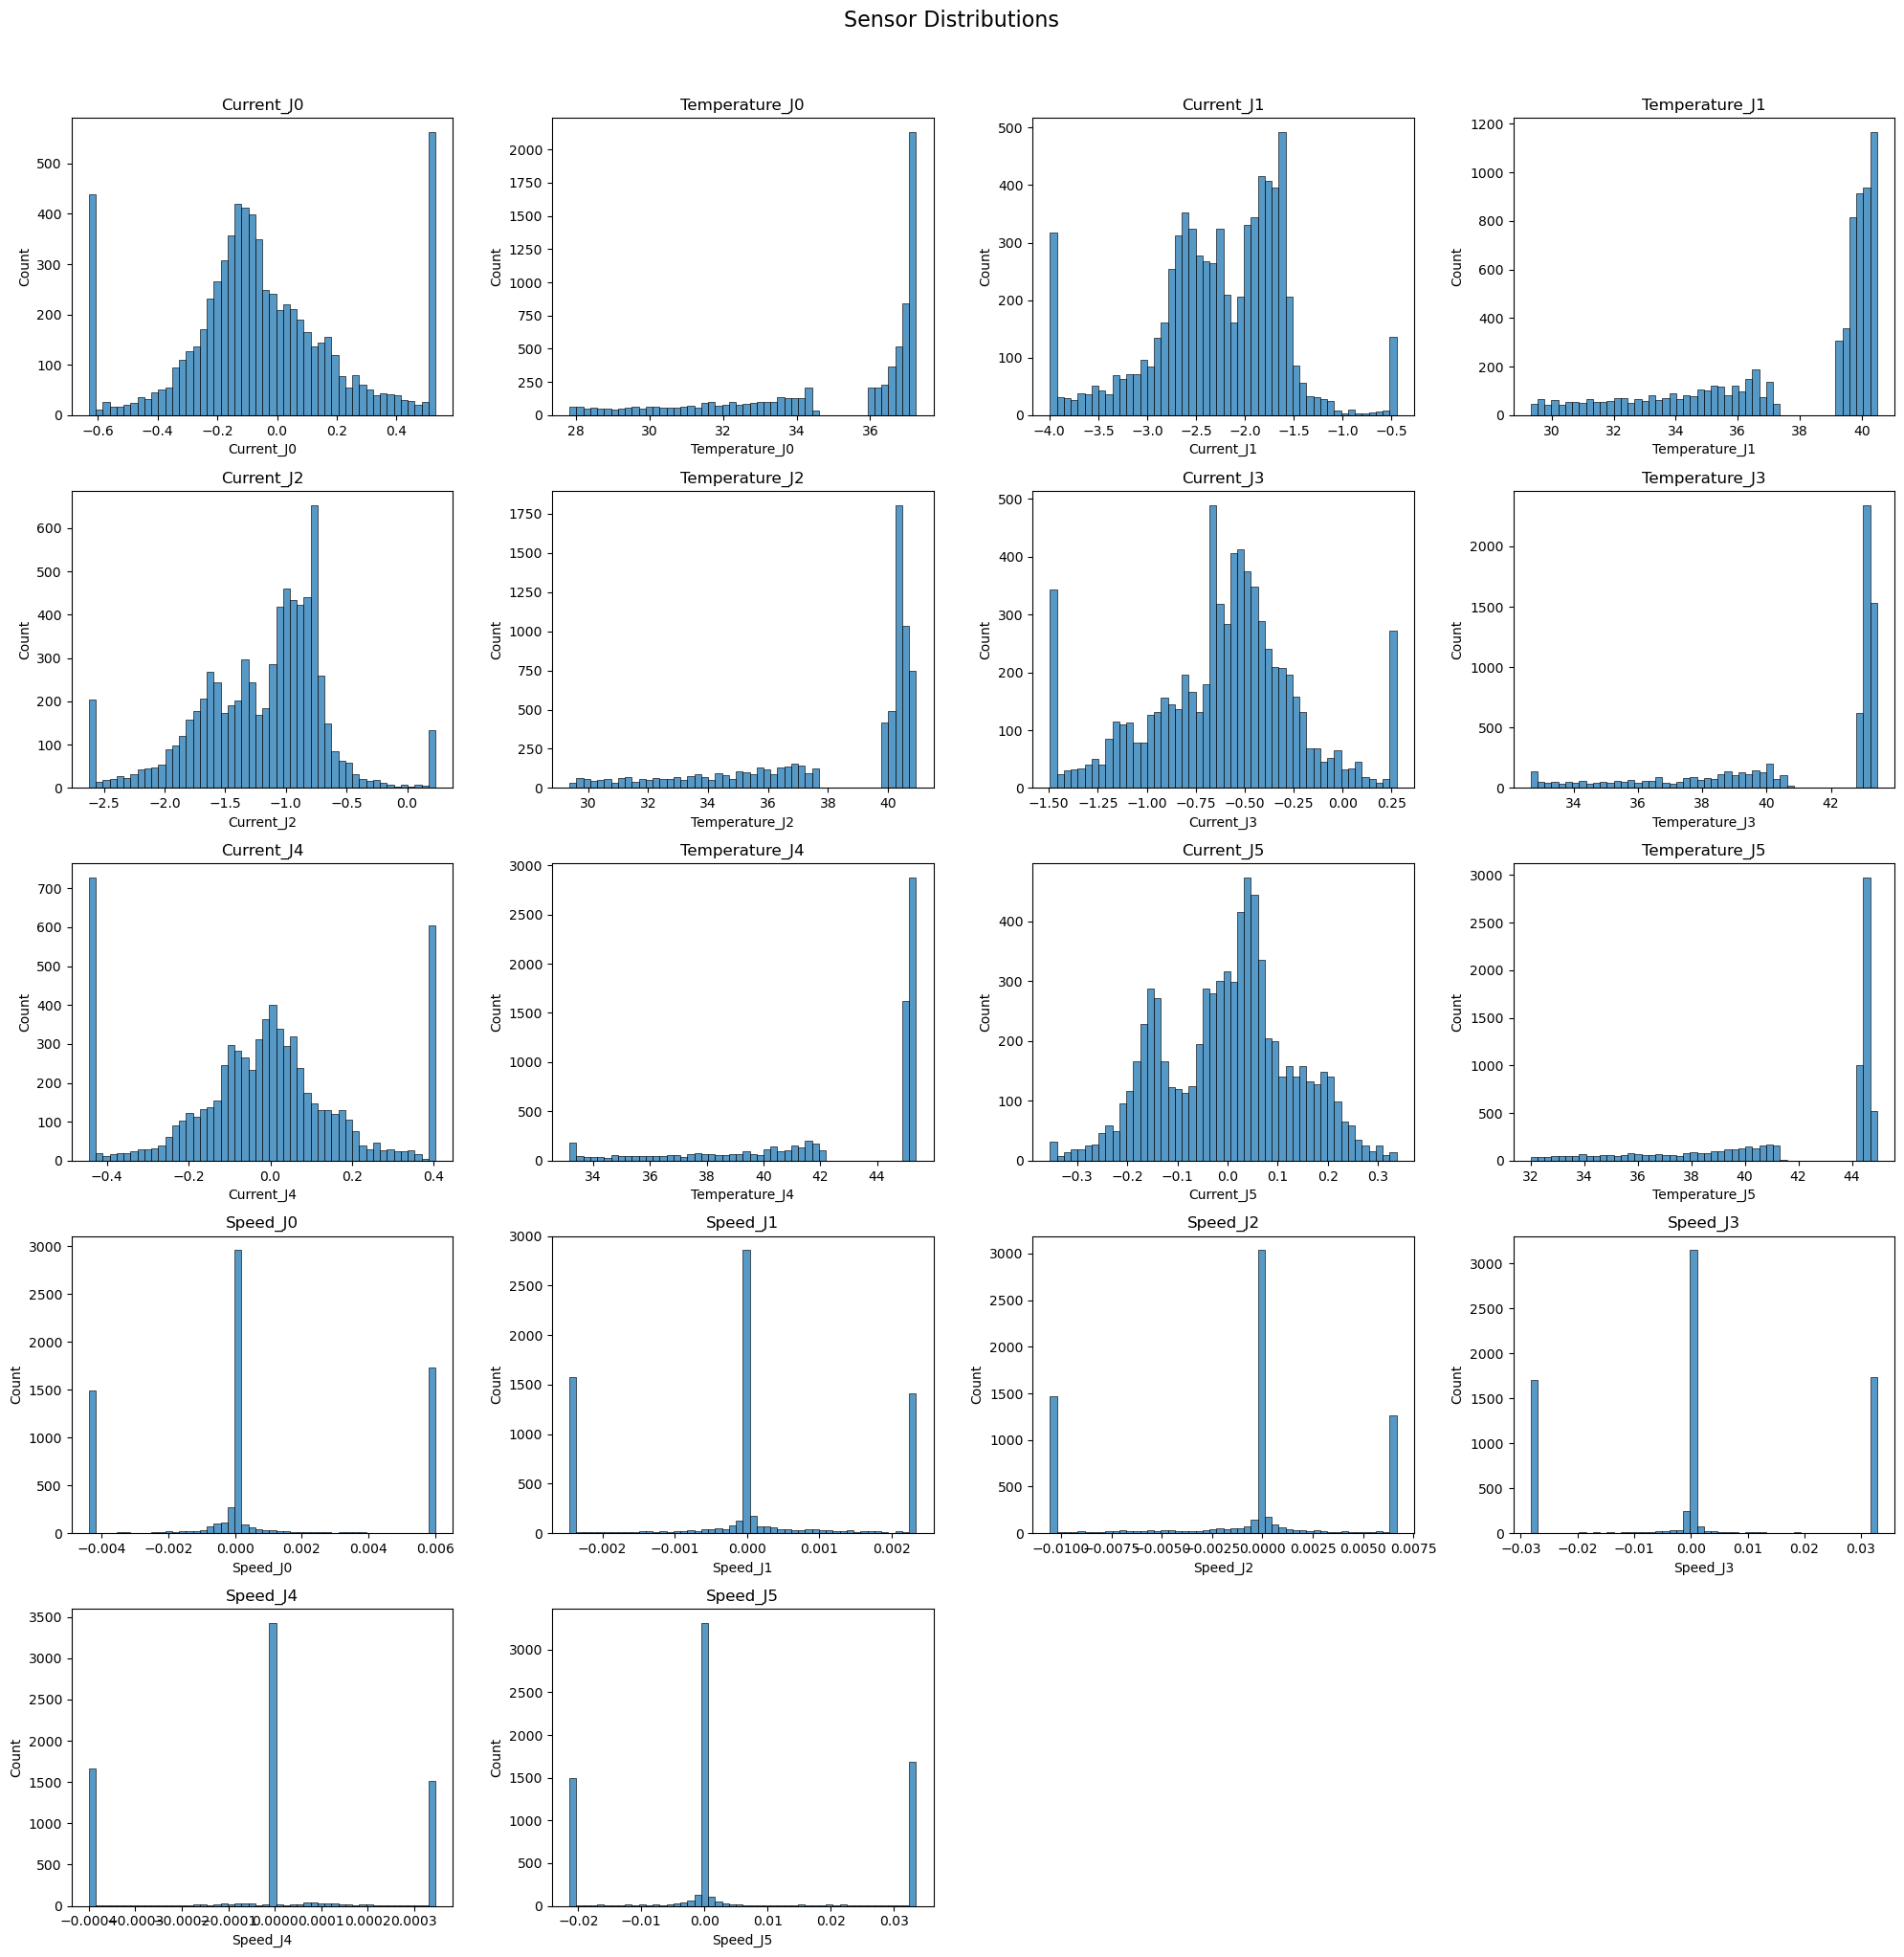

In [8]:
# Distribution plots (histograms) for every numeric sensor column
n_plots  = len(sensor_cols)
cols_row = 4
rows     = -(-n_plots // cols_row)  # ceiling division

fig, axes = plt.subplots(rows, cols_row, figsize=(20, 4*rows))
axes      = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.histplot(df[col], bins=50, ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Sensor Distributions", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Analysis of histogram plot
##### Joint Currents (Current_J0 to Current_J5)
- Most values are near 0 amps → joints are idle or under low load most of the time.
- Some joints (e.g., J1, J2, J5) show two peaks (positive and negative values) → robot moves in two directions regularly.
- A few large values (outliers) suggest short bursts of high effort or stress.
- Usefulness: These patterns help us detect high-load operations, which may indicate strain, wear, or unusual activity.

##### Joint Speeds (Speed_J0 to Speed_J5)
- Huge spike at 0 rad/s → joints are still or moving very slowly most of the time.
- Small spread of values around 0 → slow forward and backward motion.
- Rare fast movements appear as thin tails in the histogram.
- Usefulness: Can be used to create a simple rule: is_moving = |speed| > 0.1, which helps detect when the robot is actively working.
##### Joint Temperatures (Temperature_T0, Temperature_J1 to Temperature_J5)
- Most temperatures fall between 36°C and 40°C → normal operating range.
- Small bump at < 35°C indicates the warm-up phase just after the robot powers on.
- No dangerously high values detected.
- Usefulness: Good to create a warmup flag (for T < 35°C) and monitor if any joint exceeds safe temperatures (> 45–50°C in future).
##### Final Takeaways:
- Robot is idle most of the time, and movement is usually low-load and predictable.
- Directionality (positive/negative values) in current and speed is important — it tells us which way the joint is moving or pushing.
- Histograms reveal normal operating zones and rare edge cases — which are important for detecting problems early.

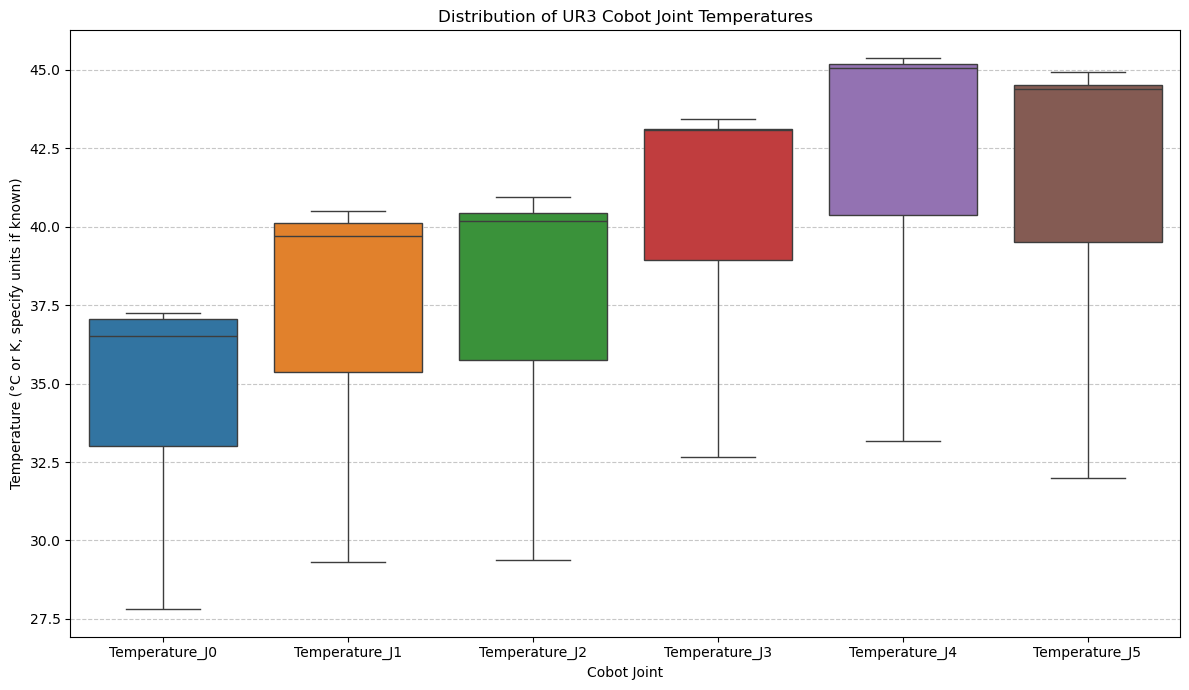

In [9]:
# Joint temperatures distribution plot
joint_temperature_columns = [
    'Temperature_J0',
    'Temperature_J1',
    'Temperature_J2',
    'Temperature_J3',
    'Temperature_J4',
    'Temperature_J5'
]
# Check if all specified columns exist in the DataFrame
missing_cols = [col for col in joint_temperature_columns if col not in df.columns]
if missing_cols:
    print(f"Error: The following joint temperature columns were not found in the data: {missing_cols}")
    print("Please update 'joint_temperature_columns' list with correct column names.")
else:
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df[joint_temperature_columns])
    plt.title('Distribution of UR3 Cobot Joint Temperatures')
    plt.xlabel('Cobot Joint')
    plt.ylabel('Temperature (°C or K, specify units if known)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Joint Temperature Analysis
- The box plot reveals a temperature gradient across the joints, with temperatures generally increasing from J0 to J5.
- J0 (Base Joint): Exhibits the lowest temperatures and least variability (median ≈ 36.5°C).
- J1 & J2 (Middle Joints): Show progressively higher medians and slightly wider distributions than J0 (J1 median ≈ 38°C, J2 median ≈ 39°C).
- J3, J4, J5 (Wrist Joints): Experience the highest temperatures.
- J4 stands out with the highest median (≈ 44°C) and the highest observed maximum temperature (≈ 45.5°C).
- Both J4 and J5 show potential outliers indicating occasional extreme temperature spikes.
This gradient likely reflects increased workload or less efficient heat dissipation further down the robot arm. The higher temperatures and outliers in J3, J4, and J5 suggest these joints may be under greater thermal stress, warranting closer monitoring for wear and potential maintenance.

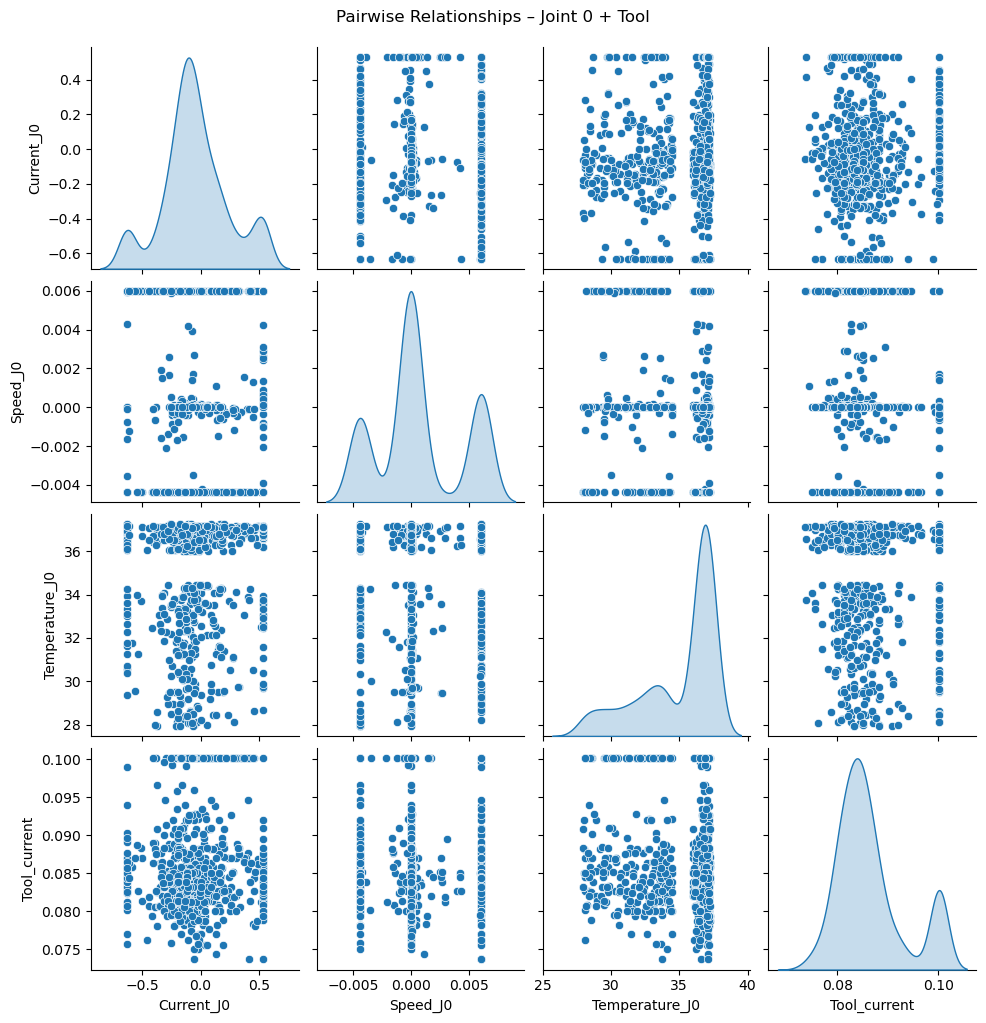

In [10]:
# Quick scatter-matrix for Joint-0 variables
subset = ['Current_J0', 'Speed_J0', 'Temperature_J0', 'Tool_current']
g = sns.pairplot(df[subset].sample(700, random_state=42), diag_kind='kde')
g.fig.suptitle("Pairwise Relationships – Joint 0 + Tool", y=1.02)
plt.show()


### Analysis of Scatter plot
##### What the above scatter plots show:
###### Current_J0 vs Speed_J0
- The points form a diagonal line → When Joint 0 moves faster, it also uses more power.
- There are two groups: one for forward movement and one for backward movement (positive vs negative speed and current).
###### Current_J0 vs Temperature_T0
- Higher power use tends to cause Joint 0 to heat up slightly.
- But even when not moving (low current), Joint 0 can still be warm — probably from the environment or leftover heat.
######  Speed_J0 vs Temperature_T0
- The faster the joint moves, the more it heats up — but the effect is not very strong.
- When the robot is idle (speed = 0), the temperature stays in a small range.
- Tool_current compared to other values
- Tool current doesn’t strongly relate to Joint 0’s current, speed, or temperature.
- This means the tool (like a gripper) is working independently from Joint 0’s motion.
###### Individual distributions (the diagonal plots)
- Current_J0: Two main levels — zero (when idle) and around -1.8 A (reverse movement).
- Speed_J0: Very often zero → robot is idle most of the time.
- Temperature_T0: Mostly between 36–40 °C → the robot reaches a stable temperature.
- Tool_current: Usually low, but sometimes spikes → tool is lightly used with occasional heavy load.
##### Takeaways
- When Joint 0 moves, it uses more power and gets a little hotter.
- The robot is idle for most of the time.
- The tool works separately from Joint 0 — its usage doesn’t impact Joint 0 much.
- These patterns can help us design better monitoring or prediction models for wear, overheating, or unusual activity.

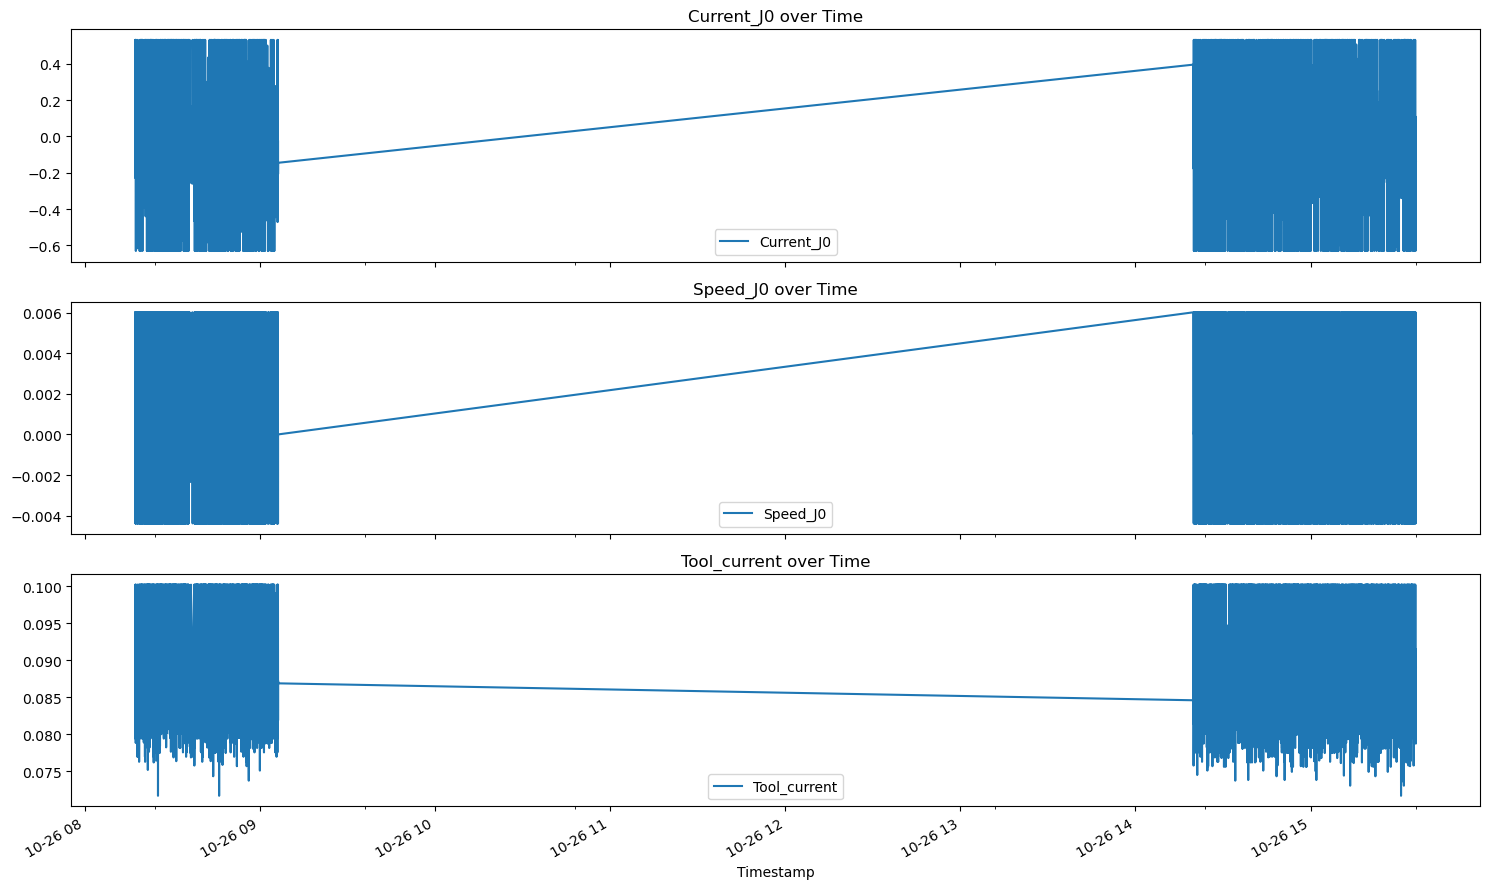

In [11]:
# Time-series illustration 
fig, ax = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
df.plot(x='Timestamp', y='Current_J0', ax=ax[0], title='Current_J0 over Time')
df.plot(x='Timestamp', y='Speed_J0',   ax=ax[1], title='Speed_J0 over Time')
df.plot(x='Timestamp', y='Tool_current', ax=ax[2], title='Tool_current over Time')
plt.tight_layout()
plt.show()

#### Analysis of Timeseries plot
##### Current_J0 over Time
- Shows how much electrical current the robot’s first joint (Joint 0) is using at each moment.
- Most of the time, the line is flat near 0 amps → Joint 0 is idle or under low load.
- Occasional spikes (both positive and negative) show active movement or resistance (such as lifting or lowering something).
##### Speed_J0 over Time
- Shows how fast Joint 0 is moving (in radians per second).
- Long flat sections at 0 rad/s indicate the robot is stationary.
- Short, sharp movements away from 0 show brief active movements.
- These usually match with the current spikes from the first plot.
##### Tool_current over Time
- Displays how much power the tool (e.g., gripper) is using.
- Mostly low → the tool is inactive or lightly used.
- Occasional sharp increases in value indicate gripping or applying force.
- These do not always align with joint motion, meaning the tool can work independently of Joint 0.
##### Key Takeaways:
- The robot is mostly idle, with short bursts of activity.
- Joint 0 current and speed often move together, confirming physical motion.
- Tool usage is independent and can indicate gripping or placing actions.
- This plot helps us visually segment robot activity into idle, movement, and tool-use phases — a foundation for predictive modeling or anomaly detection.Current_J0 over Time

# 2. Housing Prices Data

In [12]:
# Load the dataset
df_housing = pd.read_csv('AmesHousing.csv')

# Identify numerical columns based on dtype
numerical_cols = df_housing.select_dtypes(include=np.number).columns.tolist()

# Identify all object (string) columns initially
object_cols = df_housing.select_dtypes(include='object').columns.tolist()

# Define specific ordinal columns and their intended orders based on domain knowledge
# 'None' is explicitly included in orders where it represents absence/lowest rank
ordinal_features_and_orders_manual = [
    ('Street', ['Grvl', 'Pave']),
    ('Alley', ['None', 'Grvl', 'Pave']),
    ('Lot Shape', ['IR3', 'IR2', 'IR1', 'Reg']),
    ('Land Contour', ['Low', 'Bnk', 'HLS', 'Lvl']),
    ('Land Slope', ['Sev', 'Mod', 'Gtl']),
    ('Exter Qual', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Exter Cond', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Bsmt Qual', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Bsmt Cond', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Bsmt Exposure', ['None', 'No', 'Mn', 'Av', 'Gd']),
    ('BsmtFin Type 1', ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']),
    ('BsmtFin Type 2', ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']),
    ('Heating QC', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Kitchen Qual', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Functional', ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']),
    ('Fireplace Qu', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Garage Finish', ['None', 'Unf', 'RFn', 'Fin']),
    ('Garage Qual', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Garage Cond', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Paved Drive', ['N', 'P', 'Y']),
    ('Pool QC', ['None', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Fence', ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'])
]
# Extract column names for ordinal encoder
ordinal_cols = [col for col, _ in ordinal_features_and_orders_manual]
# Extract category orders for ordinal encoder
ordinal_categories = [order for _, order in ordinal_features_and_orders_manual]

# Nominal columns are all object columns not identified as ordinal
nominal_cols = [col for col in object_cols if col not in ordinal_cols]


print("Identified Numerical Columns:", numerical_cols)
print("\nIdentified Ordinal Columns:", ordinal_cols)
print("\nIdentified Nominal Categorical Columns:", nominal_cols)

Identified Numerical Columns: ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']

Identified Ordinal Columns: ['Street', 'Alley', 'Lot Shape', 'Land Contour', 'Land Slope', 'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence']

Identified Nominal Categorical Columns: ['MS Zo

Rows , Columns → (7355, 43)


,Count
dtype,
object,43
int64,28
float64,11


Shows data volume, mix of numeric vs object, and where imputation is needed.


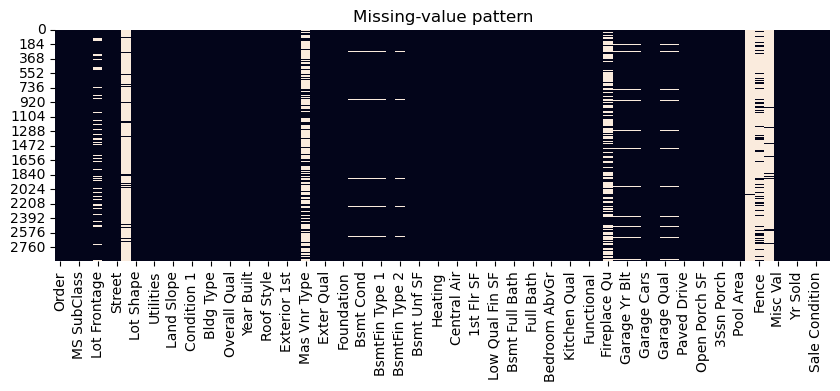

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

In [13]:
print("Rows , Columns →", df.shape)
display(df_housing.dtypes.value_counts().rename_axis('dtype').to_frame('Count'))
print("Shows data volume, mix of numeric vs object, and where imputation is needed.")
# missing-value heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(df_housing.isna(), cbar=False)
plt.title("Missing-value pattern"); plt.show()

df_housing.isna().sum().sort_values(ascending=False).head(20)

#### 2.1 Data Cleaning
- Handle imperfections in the raw data.
##### It systematically addresses missing values:
- NaNs in categorical/ordinal features that denote absence (like Pool QC) are filled with the string 'None'.
- Numerical NaNs, where 0 indicates a feature's absence (e.g., Garage Area), are filled with 0.
- Lot Frontage is imputed using a more sophisticated approach: the median value from its respective Neighborhood, which accounts for spatial correlation.
- A fallback imputation is included for Lot Frontage to catch any remaining NaNs by filling them with the overall column median.
- Any remaining isolated NaNs in columns like Electrical are imputed with their mode.
- A specific correction is applied to Garage Yr Blt to ensure consistency with Garage Area.
- Finally, extreme outliers in Gr Liv Area are removed to prevent them from disproportionately influencing model training.
- The output confirms the success of the cleaning by showing columns that still have missing values, which should ideally be none or very few.

In [14]:
import os
# Missing Value Imputation: Categorical/Ordinal features (fill 'None')
# Applies to features where 'NA' means 'no such feature'
for col in ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu', 'Garage Type',
            'Garage Finish', 'Garage Qual', 'Garage Cond', 'Bsmt Qual', 'Bsmt Cond',
            'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Mas Vnr Type']:
    if col in df_housing.columns: # Check if column exists (e.g., 'Pool QC' might not always be present)
        df_housing[col] = df_housing[col].fillna('None')

# Missing Value Imputation: Numerical features (fill 0)
# Applies to numerical features where 'NA' means 'zero value' or 'absence'
for col in ['Garage Yr Blt', 'Garage Area', 'Garage Cars', 'BsmtFin SF 1', 'BsmtFin SF 2',
            'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Mas Vnr Area',
            'Pool Area', 'Misc Val']:
    if col in df_housing.columns:
        df_housing[col] = df_housing[col].fillna(0)

# Lot Frontage: Impute with median of the neighborhood for spatial consistency
if 'Lot Frontage' in df_housing.columns and 'Neighborhood' in df_housing.columns:
    df_housing['Lot Frontage'] = df_housing.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

# Fallback for Lot Frontage if any NaNs remain after neighborhood imputation
if 'Lot Frontage' in df_housing.columns and df_housing['Lot Frontage'].isnull().any():
    global_median_lot_frontage = df_housing['Lot Frontage'].median()
    df_housing['Lot Frontage'] = df_housing['Lot Frontage'].fillna(global_median_lot_frontage)


# Remaining isolated missing values (Electrical, MS Zoning) - impute with mode
# These are typically nominal categorical features with few missing values
for col in ['Electrical', 'MS Zoning']:
    if col in df_housing.columns and df_housing[col].isnull().any():
        df_housing[col] = df_housing[col].fillna(df_housing[col].mode()[0])

# Special handling for Garage Yr Blt: if 0 (missing or no garage) but garage area exists, use Year Built
if 'Garage Yr Blt' in df_housing.columns and 'Garage Area' in df_housing.columns and 'Year Built' in df_housing.columns:
    df_housing.loc[(df_housing['Garage Yr Blt'] == 0) & (df_housing['Garage Area'] > 0), 'Garage Yr Blt'] = df_housing['Year Built']

# Outlier Removal: Remove houses with excessively large living areas to improve model robustness
if 'Gr Liv Area' in df_housing.columns:
    df_housing = df_housing[df_housing['Gr Liv Area'] < 4500]

print("Data cleaning complete. Missing values remaining (if any, should be minimal for key columns):")
print(df_housing.isnull().sum()[df_housing.isnull().sum() > 0]) #Save cleaned data
df.to_csv(os.path.join('../Data-Modeling','AmesHousing-cleaned.csv'), index=False)

Data cleaning complete. Missing values remaining (if any, should be minimal for key columns):
Series([], dtype: int64)


### 2.2 Housing data EDA

Reveals right-skew in raw price and shows that log1p gives a near-normal shape – advantageous for linear regression


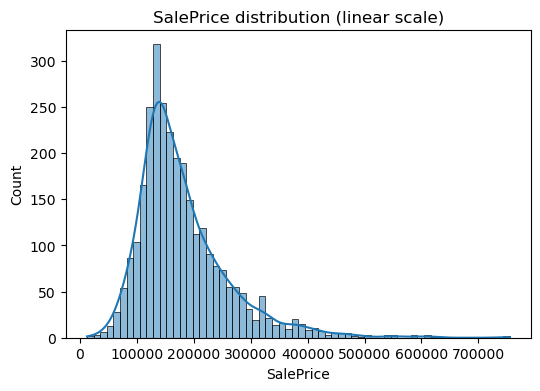

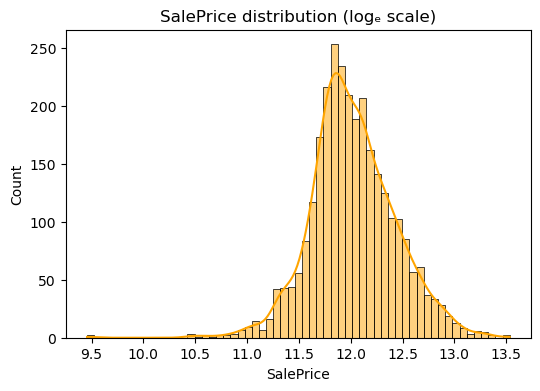

In [15]:
## Price vaiable distribution
print("Reveals right-skew in raw price and shows that log1p gives a near-normal shape – advantageous for linear regression")
plt.figure(figsize=(6,4))
sns.histplot(df_housing["SalePrice"], kde=True)
plt.title("SalePrice distribution (linear scale)")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(df_housing["SalePrice"]), kde=True, color="orange")
plt.title("SalePrice distribution (logₑ scale)")
plt.show()

Highlights: Strongest -> Overall Qual, Gr Liv Area, Total Bsmt SF. Multicollinearity signals -> Garage Cars vs Garage Area.


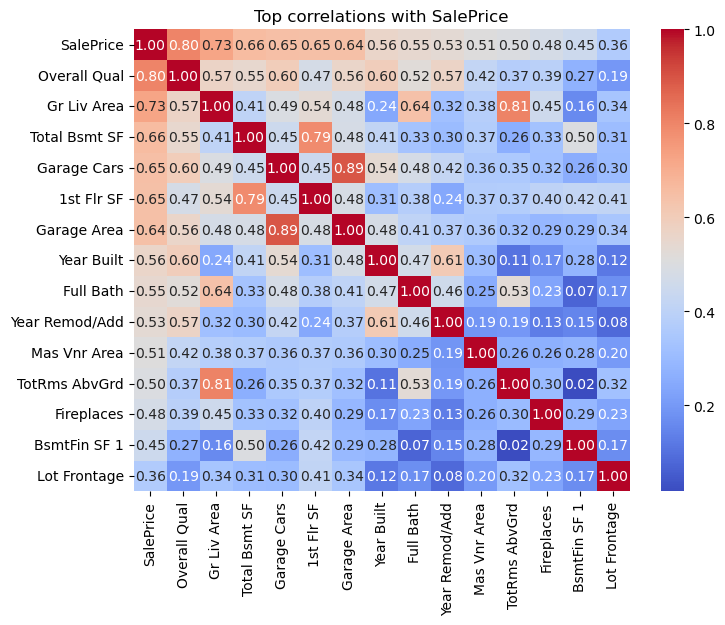

In [16]:
## Correlation matrix between features
print("Highlights: Strongest -> Overall Qual, Gr Liv Area, Total Bsmt SF. Multicollinearity signals -> Garage Cars vs Garage Area.")
num_df_housing   = df_housing.select_dtypes("number")
corr_top = num_df_housing.corr()["SalePrice"].abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(8,6))
sns.heatmap(num_df_housing[corr_top].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top correlations with SalePrice"); plt.show()

Visualises median shifts; confirms ordinal relationships and identifies nominal categories that drive price.


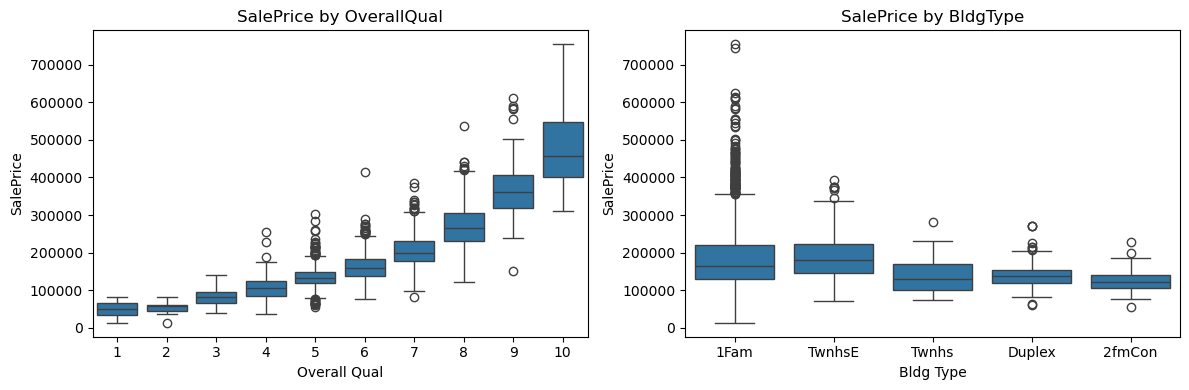

In [17]:
## Categorical impact
print("Visualises median shifts; confirms ordinal relationships and identifies nominal categories that drive price.")
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x="Overall Qual", y="SalePrice", data=df_housing, ax=ax[0])
ax[0].set_title("SalePrice by OverallQual")
sns.boxplot(x="Bldg Type", y="SalePrice", data=df_housing, ax=ax[1])
ax[1].set_title("SalePrice by BldgType")
plt.tight_layout(); plt.show()

Linear trends visible for size & quality variables; check for funnel or heteroscedastic patterns before fitting OLS


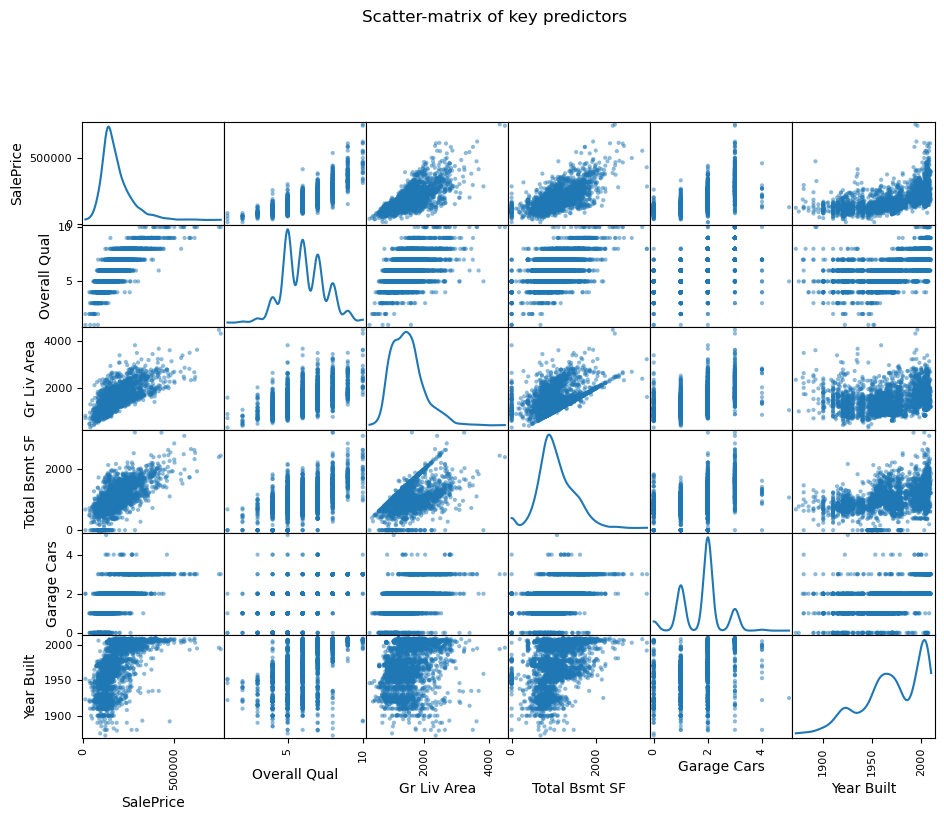

In [18]:
# Scatter matrix of most correlated predictors
print("Linear trends visible for size & quality variables; check for funnel or heteroscedastic patterns before fitting OLS")
top_vars_df_housing = ["SalePrice","Overall Qual","Gr Liv Area","Total Bsmt SF","Garage Cars","Year Built"]
scatter_matrix(df_housing[top_vars_df_housing], figsize=(11, 8), diagonal="kde")
plt.suptitle("Scatter-matrix of key predictors", y=1.02); plt.show()

#### Key EDA Takeaways
- SalePrice is right-skewed → using log1p(SalePrice) will satisfy linearity & homoscedasticity assumptions better.
- Top numeric drivers: Overall Qual, Gr Liv Area, Total Bsmt SF, Garage Cars.
- Categoricals matter: Bldg Type, Neighborhood, garage type/finish show clear price stratification.
- Potential multicollinearity: high correlation among size features (e.g., 1st vs Total floor SF) 
- Missingness concentrated in masonry & basement fields – plan median/most-frequent imputation or domain-specific fills.
Now you have a clear statistical and visual foundation to specify transformations (log target, scaling)
Based on thsi we will do OLS, Ridge for regression models.

## 3. Regression Models

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For model building
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet # Added ElasticNet
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [20]:
# Load the dataset
df = pd.read_csv('AmesHousing.csv')

# Drop irrelevant columns immediately
df = df.drop(['Order', 'PID', 'Utilities'], axis=1)

# Separate features (X_temp) from the target (SalePrice) for column identification
X_temp = df.drop('SalePrice', axis=1)

# Identify numerical columns based on dtype
numerical_cols = X_temp.select_dtypes(include=np.number).columns.tolist()

# Identify all object (string) columns initially
object_cols = X_temp.select_dtypes(include='object').columns.tolist()

# Define specific ordinal columns and their intended orders based on domain knowledge
# 'None' is explicitly included in orders where it represents absence/lowest rank
ordinal_features_and_orders_manual = [
    ('Street', ['Grvl', 'Pave']),
    ('Alley', ['None', 'Grvl', 'Pave']),
    ('Lot Shape', ['IR3', 'IR2', 'IR1', 'Reg']),
    ('Land Contour', ['Low', 'Bnk', 'HLS', 'Lvl']),
    ('Land Slope', ['Sev', 'Mod', 'Gtl']),
    ('Exter Qual', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Exter Cond', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Bsmt Qual', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Bsmt Cond', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Bsmt Exposure', ['None', 'No', 'Mn', 'Av', 'Gd']),
    ('BsmtFin Type 1', ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']),
    ('BsmtFin Type 2', ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']),
    ('Heating QC', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Kitchen Qual', ['Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Functional', ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']),
    ('Fireplace Qu', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Garage Finish', ['None', 'Unf', 'RFn', 'Fin']),
    ('Garage Qual', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Garage Cond', ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Paved Drive', ['N', 'P', 'Y']),
    ('Pool QC', ['None', 'Fa', 'TA', 'Gd', 'Ex']),
    ('Fence', ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'])
]
# Extract column names for ordinal encoder
ordinal_cols = [col for col, _ in ordinal_features_and_orders_manual]
# Extract category orders for ordinal encoder
ordinal_categories = [order for _, order in ordinal_features_and_orders_manual]

# Nominal columns are all object columns not identified as ordinal
nominal_cols = [col for col in object_cols if col not in ordinal_cols]


print("Identified Numerical Columns:", numerical_cols)
print("\nIdentified Ordinal Columns:", ordinal_cols)
print("\nIdentified Nominal Categorical Columns:", nominal_cols)

Identified Numerical Columns: ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold']

Identified Ordinal Columns: ['Street', 'Alley', 'Lot Shape', 'Land Contour', 'Land Slope', 'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating QC', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence']

Identified Nominal Categorical Columns: ['MS Zoning', 'Lot Config', 'Neighbo

#### Analysis: Data Loading and Initial Column Identification
- Data Ingestion: Loaded the AmesHousing.csv dataset.
- Initial Cleanup: Dropped immediately irrelevant columns (Order, PID, Utilities) to streamline the dataset.
- Feature-Target Separation: Divided the dataset into features (X_temp) and the target variable (SalePrice).
- Column Categorization: Automatically identified numerical columns.
- Manually defined and extracted ordinal categorical columns with their specific ordered categories based on domain knowledge. Remaining object-type columns were classified as nominal categorical.
- Importance: This step is crucial for applying appropriate preprocessing techniques (e.g., scaling for numerical, specific encoding for ordinal/nominal) later.

In [21]:
# Missing Value Imputation: Categorical/Ordinal features (fill 'None')
# Applies to features where 'NA' means 'no such feature'
for col in ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu', 'Garage Type',
            'Garage Finish', 'Garage Qual', 'Garage Cond', 'Bsmt Qual', 'Bsmt Cond',
            'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Mas Vnr Type']:
    if col in df.columns: # Check if column exists (e.g., 'Pool QC' might not always be present)
        df[col] = df[col].fillna('None')

# Missing Value Imputation: Numerical features (fill 0)
# Applies to numerical features where 'NA' means 'zero value' or 'absence'
for col in ['Garage Yr Blt', 'Garage Area', 'Garage Cars', 'BsmtFin SF 1', 'BsmtFin SF 2',
            'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Mas Vnr Area',
            'Pool Area', 'Misc Val']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Lot Frontage: Impute with median of the neighborhood for spatial consistency
if 'Lot Frontage' in df.columns and 'Neighborhood' in df.columns:
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

# Fallback for Lot Frontage if any NaNs remain after neighborhood imputation
if 'Lot Frontage' in df.columns and df['Lot Frontage'].isnull().any():
    global_median_lot_frontage = df['Lot Frontage'].median()
    df['Lot Frontage'] = df['Lot Frontage'].fillna(global_median_lot_frontage)


# Remaining isolated missing values (Electrical, MS Zoning) - impute with mode
# These are typically nominal categorical features with few missing values
for col in ['Electrical', 'MS Zoning']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Special handling for Garage Yr Blt: if 0 (missing or no garage) but garage area exists, use Year Built
if 'Garage Yr Blt' in df.columns and 'Garage Area' in df.columns and 'Year Built' in df.columns:
    df.loc[(df['Garage Yr Blt'] == 0) & (df['Garage Area'] > 0), 'Garage Yr Blt'] = df['Year Built']

# Outlier Removal: Remove houses with excessively large living areas to improve model robustness
if 'Gr Liv Area' in df.columns:
    df = df[df['Gr Liv Area'] < 4500]

print("Data cleaning complete. Missing values remaining (if any, should be minimal for key columns):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Data cleaning complete. Missing values remaining (if any, should be minimal for key columns):
Series([], dtype: int64)


#### Analysis: Cleaning
- Missing Value Strategy (Categorical/Ordinal): NaNs in columns like Pool QC, Alley, Bsmt Qual, etc., were imputed with the string 'None', signifying the absence of that feature.
- Missing Value Strategy (Numerical): NaNs in numerical columns such as Garage Area, Total Bsmt SF, etc., were imputed with 0, indicating the absence of a value or a zero quantity.
- Contextual Imputation (Lot Frontage): NaNs in Lot Frontage were filled using the median Lot Frontage of their respective neighborhoods to preserve spatial relationships. A global median fallback was included.
- Mode Imputation: Isolated missing values in columns like Electrical and MS Zoning were filled with their respective modes.
- Data Consistency: Corrected Garage Yr Blt values where 0 was present but a garage existed, using Year Built for consistency.
- Outlier Removal: Extreme outliers in Gr Liv Area (gross living area) were removed to prevent them from skewing model training and improving robustness.

In [22]:
# Create new features by combining existing square footage
if all(col in df.columns for col in ['1st Flr SF', '2nd Flr SF', 'Total Bsmt SF']):
    df['TotalSF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF']

# Create total bathroom count
if all(col in df.columns for col in ['Full Bath', 'Half Bath', 'Bsmt Full Bath', 'Bsmt Half Bath']):
    df['TotalBath'] = df['Full Bath'] + (0.5 * df['Half Bath']) + df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath'])

# Create total porch square footage
if all(col in df.columns for col in ['Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch']):
    df['TotalPorchSF'] = df['Wood Deck SF'] + df['Open Porch SF'] + df['Enclosed Porch'] + df['3Ssn Porch'] + df['Screen Porch']

# Create age-related features
if all(col in df.columns for col in ['Yr Sold', 'Year Built']):
    df['HouseAge'] = df['Yr Sold'] - df['Year Built']

if all(col in df.columns for col in ['Yr Sold', 'Year Remod/Add']):
    df['RemodelAge'] = df['Yr Sold'] - df['Year Remod/Add']
    # Ensure remodel age is not negative (if remodel year is after sold year)
    df.loc[df['RemodelAge'] < 0, 'RemodelAge'] = 0

if all(col in df.columns for col in ['Yr Sold', 'Garage Yr Blt']):
    df['GarageAge'] = df['Yr Sold'] - df['Garage Yr Blt']
    # Ensure garage age is not negative
    df.loc[df['GarageAge'] < 0, 'GarageAge'] = 0

# Create interaction features
if all(col in df.columns for col in ['Overall Qual', 'Gr Liv Area']):
    df['OverallQual_GrLivArea'] = df['Overall Qual'] * df['Gr Liv Area']
if all(col in df.columns for col in ['Overall Qual', 'TotalSF']):
    df['OverallQual_TotalSF'] = df['Overall Qual'] * df['TotalSF']

# Create binary existence features (0 or 1)
if 'Pool Area' in df.columns:
    df['HasPool'] = (df['Pool Area'] > 0).astype(int)
if '2nd Flr SF' in df.columns:
    df['Has2ndFloor'] = (df['2nd Flr SF'] > 0).astype(int)
if 'Garage Area' in df.columns:
    df['HasGarage'] = (df['Garage Area'] > 0).astype(int)
if 'Total Bsmt SF' in df.columns:
    df['HasBsmt'] = (df['Total Bsmt SF'] > 0).astype(int)
if 'Fireplaces' in df.columns:
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)

# Create ratio feature (average square footage per room)
if all(col in df.columns for col in ['Gr Liv Area', 'TotRms AbvGrd']):
    df['AvgRoomSF'] = df.apply(lambda row: row['Gr Liv Area'] / (row['TotRms AbvGrd'] if row['TotRms AbvGrd'] > 0 else 1), axis=1)

# Final type conversion for all engineered features to ensure they are numeric
# and handle any NaNs that might arise from coercion (e.g., division by zero)
engineered_features_list = [
    'TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodelAge', 'GarageAge',
    'OverallQual_GrLivArea', 'OverallQual_TotalSF', 'HasPool', 'Has2ndFloor',
    'HasGarage', 'HasBsmt', 'HasFireplace', 'AvgRoomSF'
]
for col in engineered_features_list:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("Feature engineering complete. First 5 rows with new features:")
print(df.head())

Feature engineering complete. First 5 rows with new features:
   MS SubClass MS Zoning  Lot Frontage  Lot Area Street Alley Lot Shape  \
0           20        RL         141.0     31770   Pave  None       IR1   
1           20        RH          80.0     11622   Pave  None       Reg   
2           20        RL          81.0     14267   Pave  None       IR1   
3           20        RL          93.0     11160   Pave  None       Reg   
4           60        RL          74.0     13830   Pave  None       IR1   

  Land Contour Lot Config Land Slope  ... RemodelAge GarageAge  \
0          Lvl     Corner        Gtl  ...         50      50.0   
1          Lvl     Inside        Gtl  ...         49      49.0   
2          Lvl     Corner        Gtl  ...         52      52.0   
3          Lvl     Corner        Gtl  ...         42      42.0   
4          Lvl     Inside        Gtl  ...         12      13.0   

  OverallQual_GrLivArea OverallQual_TotalSF HasPool  Has2ndFloor  HasGarage  \
0          

### Analysis: Feature Engineering
- Combined Area Features: Created TotalSF (total square footage), TotalBath (total bathrooms), and TotalPorchSF (total porch area) to provide comprehensive size metrics.
- Age-Related Features: Calculated HouseAge, RemodelAge, and GarageAge from year columns, providing insight into the property's age and renovation status. Negative ages were corrected to zero.
- Interaction Features: Introduced OverallQual_GrLivArea and OverallQual_TotalSF by multiplying overall quality with area, capturing synergistic effects where high quality combined with large size might be particularly valuable.
- Binary Existence Features: Created HasPool, Has2ndFloor, HasGarage, HasBsmt, and HasFireplace (0 or 1 flags) to indicate the presence or absence of key amenities.
- Ratio Feature: Derived AvgRoomSF (average square footage per room) to reflect spaciousness.
- Type Coercion: Ensured all engineered features were numeric, filling any NaNs resulting from calculations with 0

In [23]:
# Separate features (X) and target (y)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Preprocessing Pipeline Setup ---
# Define the ColumnTransformer using the identified column lists from Cell 2
# Note: For simple linear regression, we'll manually select a feature from X_train
# before passing it to the pipeline that only has a scaler.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')), # Impute NaNs with the median
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough'
)

# --- Model Pipelines and Training ---

print("\n--- Starting Model Training ---")

# 1. Simple Linear Regression Pipeline (using 'Gr Liv Area' as the single feature)
# Create a specific preprocessor for just 'Gr Liv Area'
simple_lr_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit and transform only the 'Gr Liv Area' column
X_train_simple_lr = simple_lr_preprocessor.fit_transform(X_train[['Gr Liv Area']])
X_test_simple_lr = simple_lr_preprocessor.transform(X_test[['Gr Liv Area']])

simple_linear_model = LinearRegression()
print("\nTraining Simple Linear Regression (using Gr Liv Area)...")
simple_linear_model.fit(X_train_simple_lr, y_train)
y_pred_simple_linear = simple_linear_model.predict(X_test_simple_lr)
mse_simple_linear = mean_squared_error(y_test, y_pred_simple_linear)
r2_simple_linear = r2_score(y_test, y_pred_simple_linear)
print(f"Simple Linear Regression MSE: {mse_simple_linear:.4f}")
print(f"Simple Linear Regression R-squared: {r2_simple_linear:.4f}")

print("\nSample Simple Linear Regression Predictions vs. Actuals (first 5):")
comparison_df_simple_linear = pd.DataFrame({'Actual SalePrice': y_test.head(),
                                            'Predicted SalePrice (Simple LR)': y_pred_simple_linear[:5].round(2)})
print(comparison_df_simple_linear)


# 2. Multiple Linear Regression Pipeline (using all preprocessed features)
multiple_linear_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', LinearRegression())])
print("\nTraining Multiple Linear Regression (using all features)...")
multiple_linear_pipeline.fit(X_train, y_train)
y_pred_multiple_linear = multiple_linear_pipeline.predict(X_test)
mse_multiple_linear = mean_squared_error(y_test, y_pred_multiple_linear)
r2_multiple_linear = r2_score(y_test, y_pred_multiple_linear)
print(f"Multiple Linear Regression MSE: {mse_multiple_linear:.4f}")
print(f"Multiple Linear Regression R-squared: {r2_multiple_linear:.4f}")

print("\nSample Multiple Linear Regression Predictions vs. Actuals (first 5):")
comparison_df_multiple_linear = pd.DataFrame({'Actual SalePrice': y_test.head(),
                                              'Predicted SalePrice (Multiple LR)': y_pred_multiple_linear[:5].round(2)})
print(comparison_df_multiple_linear)


# 3. Ridge Regression Pipeline with GridSearchCV for hyperparameter tuning
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Ridge())])
param_grid_ridge = {'regressor__alpha': np.logspace(-4, 4, 9)} # From 0.0001 to 10000, 9 values
grid_search_ridge = GridSearchCV(ridge_pipeline, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
print("\nTraining Ridge Regression with GridSearchCV...")
grid_search_ridge.fit(X_train, y_train)
best_ridge_model = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"\nRidge Regression - Best Alpha: {grid_search_ridge.best_params_['regressor__alpha']:.6f}")
print(f"Ridge Regression - Best Cross-Validation MSE: {-grid_search_ridge.best_score_:.4f}")
print(f"Ridge Regression - Test Set MSE: {mse_ridge:.4f}")
print(f"Ridge Regression - Test Set R-squared: {r2_ridge:.4f}")

print("\nSample Ridge Regression Predictions vs. Actuals (first 5):")
comparison_df_ridge = pd.DataFrame({'Actual SalePrice': y_test.head(),
                                    'Predicted SalePrice (Ridge)': y_pred_ridge[:5].round(2)})
print(comparison_df_ridge)

print("\n--- Model Training Complete ---")


--- Starting Model Training ---

Training Simple Linear Regression (using Gr Liv Area)...
Simple Linear Regression MSE: 3618474060.8196
Simple Linear Regression R-squared: 0.5510

Sample Simple Linear Regression Predictions vs. Actuals (first 5):
      Actual SalePrice  Predicted SalePrice (Simple LR)
2393            298236                        282494.72
196             132000                        175768.30
2310            183500                        183978.03
1732            198444                        209177.32
1100            250000                        260716.15

Training Multiple Linear Regression (using all features)...
Multiple Linear Regression MSE: 425817827.3912
Multiple Linear Regression R-squared: 0.9472

Sample Multiple Linear Regression Predictions vs. Actuals (first 5):
      Actual SalePrice  Predicted SalePrice (Multiple LR)
2393            298236                          317922.17
196             132000                          139491.87
2310            183

### Modeling (Simple, Multiple, and Ridge Regression)
- Data Preparation: Split the data into training and testing sets (X_train, X_test, y_train, y_test).
- Preprocessor Pipeline: Established a ColumnTransformer to handle different types of features: numerical features were imputed with medians and scaled; ordinal features were encoded with specified orders; and nominal features were one-hot encoded.

#### Simple Linear Regression:
- Focus: Trained using only the Gr Liv Area feature, demonstrating basic linear modeling with a single predictor.
- Preprocessing: Applied a specific imputer and scaler only to Gr Liv Area.
- Evaluation: Measured performance using Mean Squared Error (MSE) and R-squared
#### Multiple Linear Regression:
- Focus: Utilized all preprocessed features to train a standard LinearRegression model, representing a more complex linear relationship.
- Preprocessing: Used the comprehensive ColumnTransformer.
- Evaluation: Assessed performance with MSE and R-squared.
#### Ridge Regression:
-Focus: Implemented Ridge (L2 regularized) regression to combat overfitting and handle multicollinearity.
- Hyperparameter Tuning: Employed GridSearchCV with 5-fold cross-validation to search for the optimal alpha (regularization strength) within a defined range.
- Evaluation: Reported the best alpha, its cross-validation MSE, and test set MSE/R-squared.
- Outcome: Provided quantitative metrics and sample predictions for all three models, allowing for comparison of their performance

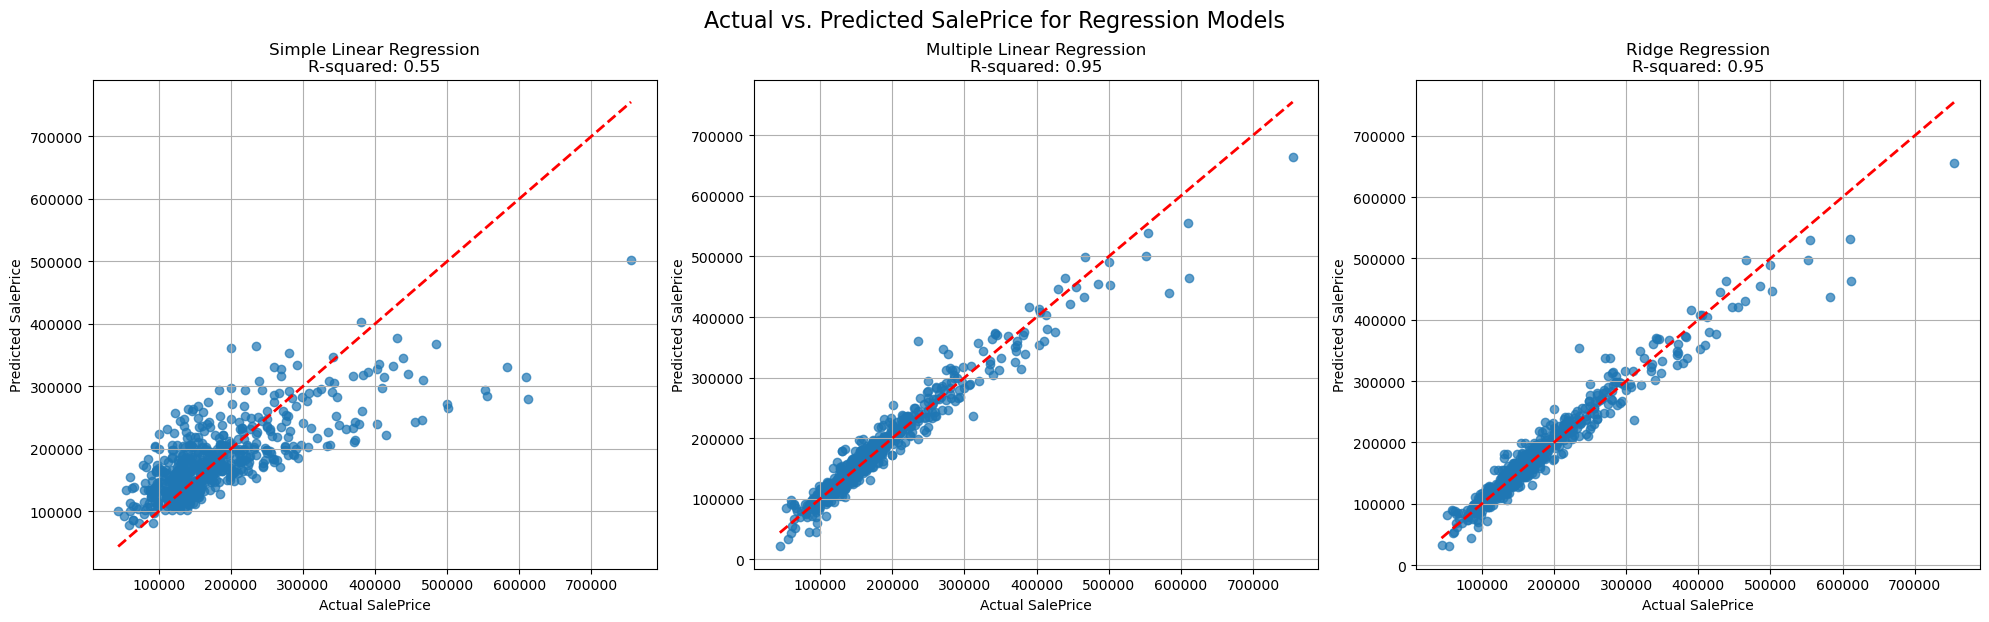

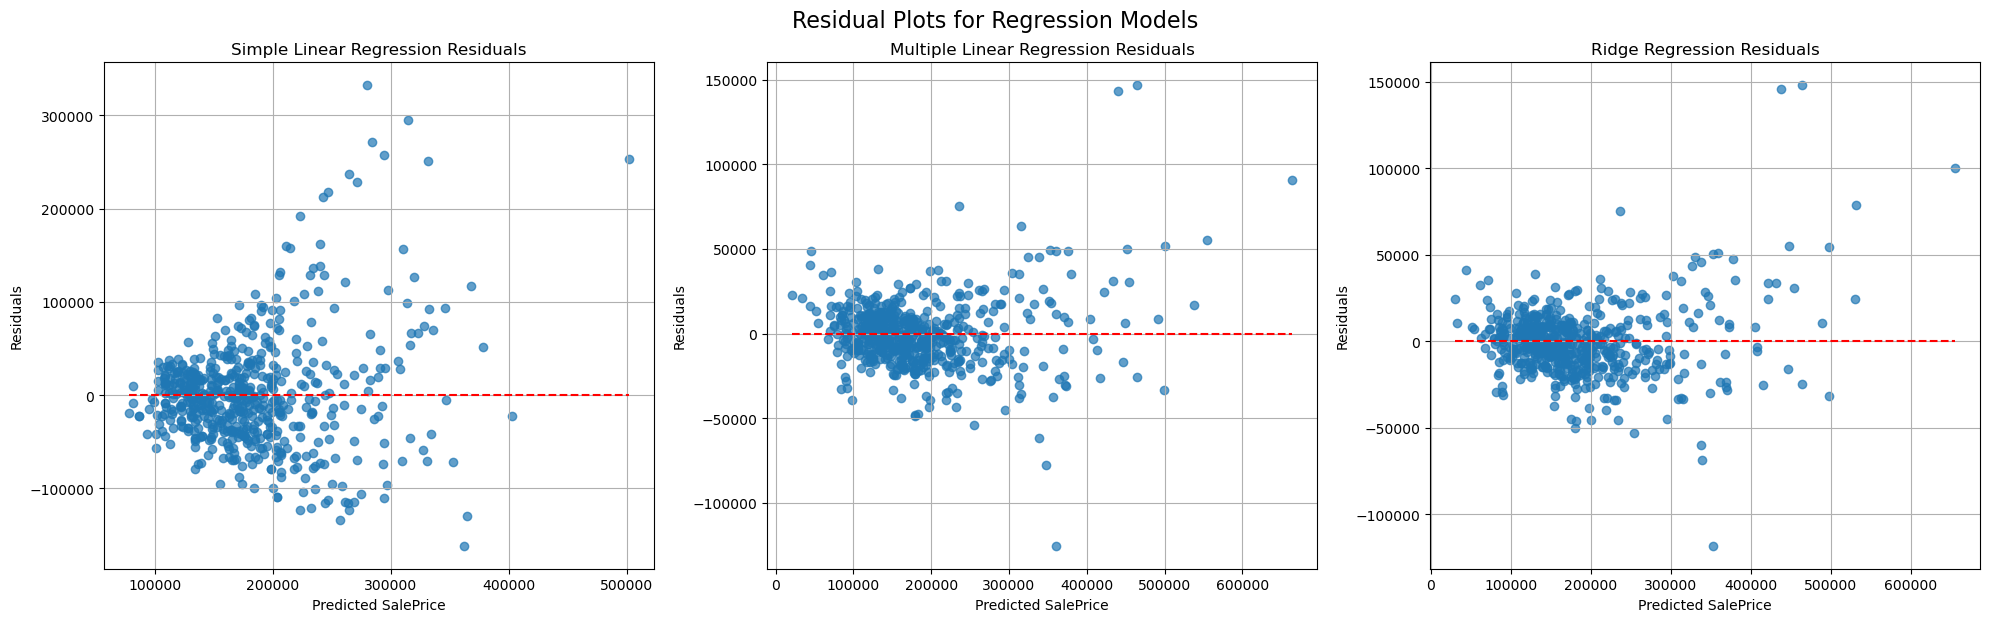

In [24]:
plt.figure(figsize=(20, 6)) # Adjusted figure size for 3 plots

# Plot for Simple Linear Regression
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_simple_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Simple Linear Regression\nR-squared: {r2_simple_linear:.2f}")
plt.grid(True)


# Plot for Multiple Linear Regression
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_multiple_linear, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Multiple Linear Regression\nR-squared: {r2_multiple_linear:.2f}")
plt.grid(True)


# Plot for Ridge Regression
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_ridge, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Ridge Regression\nR-squared: {r2_ridge:.2f}")
plt.grid(True)


plt.tight_layout()
plt.suptitle("Actual vs. Predicted SalePrice for Regression Models", y=1.03, fontsize=16)
plt.show()

# --- Residual Plots ---
plt.figure(figsize=(20, 6)) # Adjusted figure size for 3 plots

# Residual Plot for Simple Linear Regression
plt.subplot(1, 3, 1)
residuals_simple_linear = y_test - y_pred_simple_linear
plt.scatter(y_pred_simple_linear, residuals_simple_linear, alpha=0.7)
plt.hlines(0, y_pred_simple_linear.min(), y_pred_simple_linear.max(), colors='r', linestyles='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Simple Linear Regression Residuals")
plt.grid(True)


# Residual Plot for Multiple Linear Regression
plt.subplot(1, 3, 2)
residuals_multiple_linear = y_test - y_pred_multiple_linear
plt.scatter(y_pred_multiple_linear, residuals_multiple_linear, alpha=0.7)
plt.hlines(0, y_pred_multiple_linear.min(), y_pred_multiple_linear.max(), colors='r', linestyles='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Multiple Linear Regression Residuals")
plt.grid(True)


# Residual Plot for Ridge Regression
plt.subplot(1, 3, 3)
residuals_ridge = y_test - y_pred_ridge
plt.scatter(y_pred_ridge, residuals_ridge, alpha=0.7)
plt.hlines(0, y_pred_ridge.min(), y_pred_ridge.max(), colors='r', linestyles='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Ridge Regression Residuals")
plt.grid(True)


plt.tight_layout()
plt.suptitle("Residual Plots for Regression Models", y=1.03, fontsize=16)
plt.show()

### Visual Analysis of Actual vs. Predicted Plots
- The top row of plots displays the Actual vs. Predicted SalePrice for each model. The red dashed line represents perfect predictions where Actual SalePrice equals Predicted SalePrice.
##### Simple Linear Regression:
- The points are quite scattered around the red line, indicating a moderate fit.
- The R-squared of 0.55 confirms that only about 55% of the variance in SalePrice is explained by Gr Liv Area alone. This suggests that while Gr Liv Area is an important feature, it's not sufficient by itself to accurately predict house prices.
##### Multiple Linear Regression:
- The points are much tighter around the red line, especially for lower and medium prices.
- The R-squared of 0.95 shows a significant improvement, indicating that approximately 95% of the variance in SalePrice is explained by the multiple features used. This model is performing much better at capturing the relationships in the data.
##### Ridge Regression:
- Similar to Multiple Linear Regression, the points are very tightly clustered around the red line, suggesting a strong fit.
- The R-squared of 0.95 is identical to the Multiple Linear Regression in this visualization, which is expected as Ridge is a form of linear regression. Its benefit often lies in generalization rather than drastically different in-sample R-squared.

### Visual Analysis of Residual Plots
- The bottom row of plots displays the Residuals (Actual - Predicted) vs. Predicted SalePrice. Ideally, residuals should be randomly scattered around zero with no discernible pattern, indicating that the model's errors are random and that it has captured most of the underlying patterns.
##### Simple Linear Regression Residuals:
- The residuals show a clear pattern, resembling a slight curve or fanning out, especially as predicted prices increase. This indicates heteroscedasticity (non-constant variance of errors) and suggests that the single Gr Liv Area feature is not sufficient to capture the complex relationships, and the model systematically over- or under-predicts at certain price ranges.
##### Multiple Linear Regression Residuals:
- The residuals are much more randomly distributed around zero compared to the simple linear model. This suggests that the model is capturing most of the linear relationships well.
- There might still be a slight fanning out towards higher predicted values, indicating some remaining heteroscedasticity or that the model struggles slightly more with predicting higher-priced homes.
##### Ridge Regression Residuals:
- The residual plot for Ridge Regression is very similar to Multiple Linear Regression, showing a generally random scatter around zero. This is a good sign, indicating that the regularization has not significantly altered the fundamental linear relationship captured by the multiple features but rather stabilized the coefficients.
- Any slight patterns observed in the Multiple Linear Regression plot are also present here, which is expected as both are linear models using the same features

In [25]:
# K-Fold Cross-Validation Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define models to evaluate for K-Fold Cross-Validation
models_to_evaluate = {
    # Simple Linear Regression requires its own specialized preprocessor for the single feature
    "Simple Linear Regression": Pipeline(steps=[
        ('preprocessor', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])),
        ('regressor', LinearRegression())
    ]),
    "Multiple Linear Regression": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
    "Ridge Regression": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=best_ridge_model.named_steps['regressor'].alpha))])
}

print("\n--- Starting K-Fold Cross-Validation ---")

for name, model_pipeline in models_to_evaluate.items():
    mse_scores = []
    r2_scores = []

    print(f"\nEvaluating {name} with K-Fold Cross-Validation...")
    for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

        # Special handling for Simple Linear Regression: select only 'Gr Liv Area'
        if name == "Simple Linear Regression":
            # For K-fold, we need to pass a DataFrame with only the selected feature to the pipeline's fit/transform
            # The pipeline for simple LR will then handle its own imputer/scaler
            model_pipeline.fit(X_train_fold[['Gr Liv Area']], y_train_fold)
            y_pred_fold = model_pipeline.predict(X_val_fold[['Gr Liv Area']])
        else:
            model_pipeline.fit(X_train_fold, y_train_fold)
            y_pred_fold = model_pipeline.predict(X_val_fold)

        mse_scores.append(mean_squared_error(y_val_fold, y_pred_fold))
        r2_scores.append(r2_score(y_val_fold, y_pred_fold))

    print(f"{name} - Average MSE: {np.mean(mse_scores):.4f} (Std: {np.std(mse_scores):.4f})")
    print(f"{name} - Average R-squared: {np.mean(r2_scores):.4f} (Std: {np.std(r2_scores):.4f})")

print("\n--- K-Fold Cross-Validation Complete ---")


--- Starting K-Fold Cross-Validation ---

Evaluating Simple Linear Regression with K-Fold Cross-Validation...
Simple Linear Regression - Average MSE: 3023035288.3782 (Std: 348892597.1645)
Simple Linear Regression - Average R-squared: 0.5243 (Std: 0.0302)

Evaluating Multiple Linear Regression with K-Fold Cross-Validation...
Multiple Linear Regression - Average MSE: 448499466.1589 (Std: 59234016.9341)
Multiple Linear Regression - Average R-squared: 0.9282 (Std: 0.0152)

Evaluating Ridge Regression with K-Fold Cross-Validation...
Ridge Regression - Average MSE: 425499057.2411 (Std: 42962705.0205)
Ridge Regression - Average R-squared: 0.9320 (Std: 0.0123)

--- K-Fold Cross-Validation Complete ---


### Quantitative Analysis of K-Fold Cross-Validation
- The K-Fold Cross-Validation results provide a more robust and generalized view of the models' performance by averaging scores across multiple splits of the data.
##### Simple Linear Regression:
- Average MSE: 3,023,035,288.38 (Standard Deviation: 348,892,597.16)
- Average R-squared: 0.5243 (Standard Deviation: 0.0302)
- Analysis: As expected, this model has a very high MSE and a low R-squared. The high standard deviation for MSE also indicates less stable performance across different folds. This confirms that using only one feature (Gr Liv Area) is insufficient for accurate house price prediction, which aligns with the visual analysis.
##### Multiple Linear Regression:
- Average MSE: 448,499,466.16 (Standard Deviation: 59,234,016.93)
- Average R-squared: 0.9282 (Standard Deviation: 0.0152)
- Analysis: This model shows a drastic improvement over simple linear regression, with a significantly lower MSE and a very high R-squared (over 92%). The standard deviation of both metrics is relatively low, indicating stable performance. This demonstrates the power of using multiple features.
##### Ridge Regression:
- Average MSE: 425,499,057.24 (Standard Deviation: 42,962,705.02)
- Average R-squared: 0.9320 (Standard Deviation: 0.0123)
- Analysis: Ridge Regression performs slightly better than Multiple Linear Regression in terms of average MSE and R-squared. More importantly, its standard deviation for both MSE and R-squared is lower than that of Multiple Linear Regression. This suggests that Ridge Regression, by applying L2 regularization, is slightly more robust and stable in its predictions across different data subsets. It effectively reduces the variance of the model, leading to more consistent performance on unseen data.

## 4. Classification and Clustering Models

In [26]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, RocCurveDisplay,
                             accuracy_score, f1_score, classification_report, silhouette_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster 
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance 
from sklearn.cluster import AgglomerativeClustering
import multiprocessing


In [27]:
# Set the start method for multiprocessing
# This should be the FIRST thing you do related to multiprocessing in your script.
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass # If already set by another library/framework, ignore.

### 1. Classification algorithms
In housing market analytics, not every task is about predicting exact prices. 
Often, we’re more interested in categorizing homes into meaningful segments 
based on their market value — such as High, Mid, or Low price bands.
This approach helps:
- Buyers quickly identify homes within their budget.
- Sellers and agents understand where a property stands relative to others.
- Analysts and city planners assess trends across different neighborhoods or market conditions.

By converting the continuous SalePrice into discrete classes:
- We simplify the modeling task,
- Enable interpretability, and
- Support strategic decision-making like pricing tiers, marketing plans, or affordability analysis.
In this project, we classified homes based on price bands using two models — Decision Tree and k-Nearest Neighbors (k-NN) — to evaluate how well we can automatically categorize homes and gain insights from the misclassification patterns.

In [28]:

df = pd.read_csv('AmesHousing.csv')
# Drop irrelevant columns immediately
df = df.drop(['Order', 'PID', 'Utilities'], axis=1)

In [29]:
# --- 1. Handling Missing Values (Imputation) ---

# Categorical/Ordinal Columns where NaN means 'None' (absence of feature)
# These columns were identified in Cell 2. Re-list them if needed.
none_impute_cols = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
    'MasVnr Type'
]
for col in none_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# Numerical Columns where NaN means '0' (absence of quantity)
# These columns were identified in Cell 2. Re-list them if needed.
zero_impute_cols_num = [
    'Bsmt Full Bath', 'Bsmt Half Bath', 'BsmtFin SF 1', 'BsmtFin SF 2',
    'Bsmt Unf SF', 'Total Bsmt SF', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
    'MasVnr Area'
]
for col in zero_impute_cols_num:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Specific Imputation for 'Lot Frontage': Use median by 'Neighborhood'
if 'Lot Frontage' in df.columns:
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))
    # Fill any remaining NaNs (for neighborhoods with all NaNs) with overall median
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

# Mode Imputation for specific sparse NaNs (e.g., 'Electrical', 'MS Zoning')
# These columns were identified in Cell 2. Re-list them if needed.
mode_impute_cols = ['Electrical', 'MS Zoning', 'Exterior 1st', 'Exterior 2nd', 'Sale Type', 'Kitchen Qual']
for col in mode_impute_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])


# --- 2. Correcting Inconsistencies / Data Type Issues ---

# Correct 'Garage Yr Blt' where 0 might be illogical if a garage exists
# This handles cases where 'Garage Yr Blt' was 0, but 'Garage Area'/'Garage Cars' were >0
if 'Garage Yr Blt' in df.columns and 'Year Built' in df.columns:
    df.loc[df['Garage Yr Blt'] == 0, 'Garage Yr Blt'] = df['Year Built']

# Ensure 'MSSubClass' is treated as categorical
if 'MSSubClass' in df.columns:
    df['MSSubClass'] = df['MSSubClass'].astype(str)

# --- 3. Outlier Handling (Example: Gr Liv Area) ---
# Remove extreme outliers in 'Gr Liv Area' as they can skew models significantly.
# This keeps data where 'Gr Liv Area' is less than or equal to 4000 sq ft, removing very few extreme outliers.
if 'Gr Liv Area' in df.columns:
    df = df[df['Gr Liv Area'] <= 4000]

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

print(f"Shape of df after cleaning: {df.shape}")
print("\nMissing values after cleaning (should be none or minimal):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape of df after cleaning: (2925, 79)

Missing values after cleaning (should be none or minimal):
Mas Vnr Type    1774
Mas Vnr Area      23
dtype: int64


In [30]:

# --- 1. Handling Missing Values (Imputation) ---

# Categorical/Ordinal Columns where NaN means 'None' (absence of feature)
# These columns were identified in Cell 2. Re-list them if needed.
none_impute_cols = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
    'MasVnr Type'
]
for col in none_impute_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# Numerical Columns where NaN means '0' (absence of quantity)
# These columns were identified in Cell 2. Re-list them if needed.
zero_impute_cols_num = [
    'Bsmt Full Bath', 'Bsmt Half Bath', 'BsmtFin SF 1', 'BsmtFin SF 2',
    'Bsmt Unf SF', 'Total Bsmt SF', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
    'MasVnr Area'
]
for col in zero_impute_cols_num:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Specific Imputation for 'Lot Frontage': Use median by 'Neighborhood'
if 'Lot Frontage' in df.columns:
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))
    # Fill any remaining NaNs (for neighborhoods with all NaNs) with overall median
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

# Mode Imputation for specific sparse NaNs (e.g., 'Electrical', 'MS Zoning')
# These columns were identified in Cell 2. Re-list them if needed.
mode_impute_cols = ['Electrical', 'MS Zoning', 'Exterior 1st', 'Exterior 2nd', 'Sale Type', 'Kitchen Qual']
for col in mode_impute_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])


# --- 2. Correcting Inconsistencies / Data Type Issues ---

# Correct 'Garage Yr Blt' where 0 might be illogical if a garage exists
# This handles cases where 'Garage Yr Blt' was 0, but 'Garage Area'/'Garage Cars' were >0
if 'Garage Yr Blt' in df.columns and 'Year Built' in df.columns:
    df.loc[df['Garage Yr Blt'] == 0, 'Garage Yr Blt'] = df['Year Built']

# Ensure 'MSSubClass' is treated as categorical
if 'MSSubClass' in df.columns:
    df['MSSubClass'] = df['MSSubClass'].astype(str)

# --- 3. Outlier Handling (Example: Gr Liv Area) ---
# Remove extreme outliers in 'Gr Liv Area' as they can skew models significantly.
# This keeps data where 'Gr Liv Area' is less than or equal to 4000 sq ft, removing very few extreme outliers.
if 'Gr Liv Area' in df.columns:
    df = df[df['Gr Liv Area'] <= 4000]

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

print(f"Shape of df after cleaning: {df.shape}")
print("\nMissing values after cleaning (should be none or minimal):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape of df after cleaning: (2925, 79)

Missing values after cleaning (should be none or minimal):
Mas Vnr Type    1774
Mas Vnr Area      23
dtype: int64


In [31]:
# Assuming 'df' is the cleaned DataFrame from Cell 3.

# --- 1. Area-Related Features ---
# Total living square footage (above and below grade)
df['TotalSF'] = df['1st Flr SF'] + df['2nd Flr SF'] + df['Total Bsmt SF']

# Total number of bathrooms
df['TotalBath'] = df['Full Bath'] + (0.5 * df['Half Bath']) + \
                  df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath'])

# Total porch area
df['TotalPorchSF'] = df['Open Porch SF'] + df['Enclosed Porch'] + \
                     df['3Ssn Porch'] + df['Screen Porch']

# --- 2. Age-Related Features ---
# Age of the house when sold
if 'Year Built' in df.columns and 'Yr Sold' in df.columns:
    df['HouseAge'] = df['Yr Sold'] - df['Year Built']
    # Handle cases where HouseAge might be negative due to errors or future sale year
    df['HouseAge'] = df['HouseAge'].apply(lambda x: x if x >= 0 else 0)

# Age since last remodel (or construction if no remodel)
if 'Year Remod/Add' in df.columns and 'Yr Sold' in df.columns:
    df['RemodelAge'] = df['Yr Sold'] - df['Year Remod/Add']
    df['RemodelAge'] = df['RemodelAge'].apply(lambda x: x if x >= 0 else 0)

# Age of the garage when sold
if 'Garage Yr Blt' in df.columns and 'Yr Sold' in df.columns:
    df['GarageAge'] = df['Yr Sold'] - df['Garage Yr Blt']
    df['GarageAge'] = df['GarageAge'].apply(lambda x: x if x >= 0 else 0)


# --- 3. Interaction Features ---
# Interaction between overall quality and living area
if 'Overall Qual' in df.columns and 'Gr Liv Area' in df.columns:
    df['OverallQual_GrLivArea'] = df['Overall Qual'] * df['Gr Liv Area']

# Interaction between overall quality and total square footage
if 'Overall Qual' in df.columns and 'TotalSF' in df.columns:
    df['OverallQual_TotalSF'] = df['Overall Qual'] * df['TotalSF']

# --- 4. Binary/Presence Features (Flags for amenities) ---
# Indicates if a pool exists (1) or not (0)
if 'Pool QC' in df.columns:
    df['HasPool'] = df['Pool QC'].apply(lambda x: 1 if x != 'None' else 0)

# Indicates if a 2nd floor exists
if '2nd Flr SF' in df.columns:
    df['Has2ndFloor'] = df['2nd Flr SF'].apply(lambda x: 1 if x > 0 else 0)

# Indicates if a garage exists
if 'Garage Area' in df.columns: # Assuming 0 for Garage Area means no garage after imputation
    df['HasGarage'] = df['Garage Area'].apply(lambda x: 1 if x > 0 else 0)

# Indicates if a basement exists
if 'Total Bsmt SF' in df.columns: # Assuming 0 for Total Bsmt SF means no basement after imputation
    df['HasBsmt'] = df['Total Bsmt SF'].apply(lambda x: 1 if x > 0 else 0)

# Indicates if a fireplace exists
if 'Fireplaces' in df.columns:
    df['HasFireplace'] = df['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

# --- 5. Ratio Feature ---
# Average square footage per room (excluding bathrooms)
if 'TotRms AbvGrd' in df.columns and 'Gr Liv Area' in df.columns:
    df['AvgRoomSF'] = df['Gr Liv Area'] / df['TotRms AbvGrd']
    df['AvgRoomSF'] = df['AvgRoomSF'].replace([np.inf, -np.inf], 0).fillna(0) # Handle division by zero

# --- Ensure all engineered features are numeric and handle any NaNs (from operations) ---
# This is a good final check for any NaNs introduced during calculations.
for col in ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodelAge', 'GarageAge',
            'OverallQual_GrLivArea', 'OverallQual_TotalSF', 'HasPool', 'Has2ndFloor',
            'HasGarage', 'HasBsmt', 'HasFireplace', 'AvgRoomSF']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0) # Coerce to numeric, fill any new NaNs with 0

print(f"Shape of df after feature engineering: {df.shape}")
print("\nSample of engineered features (first 5 rows):")
print(df[['TotalSF', 'TotalBath', 'HouseAge', 'HasGarage', 'SalePrice']].head())

Shape of df after feature engineering: (2925, 93)

Sample of engineered features (first 5 rows):
   TotalSF  TotalBath  HouseAge  HasGarage  SalePrice
0   2736.0        2.0        50          1     215000
1   1778.0        1.0        49          1     105000
2   2658.0        1.5        52          1     172000
3   4220.0        3.5        42          1     244000
4   2557.0        2.5        13          1     189900


--- Column Categorization for Preprocessing ---
Numerical Columns (50): ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodelAge', 'GarageAge', 'OverallQual_GrLivArea', 'OverallQual_TotalSF', 'HasPool', 'Has2ndFloor', 'HasGarage', 'HasBsmt', 'HasFireplace', 'AvgRoomSF']
Ordinal Columns (19): ['Lot Shape', 'Alley', 'Bsmt Qual', 'Bsmt Cond', 'Exter Qual', 'Exter Cond', 'Heating QC', 'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Co

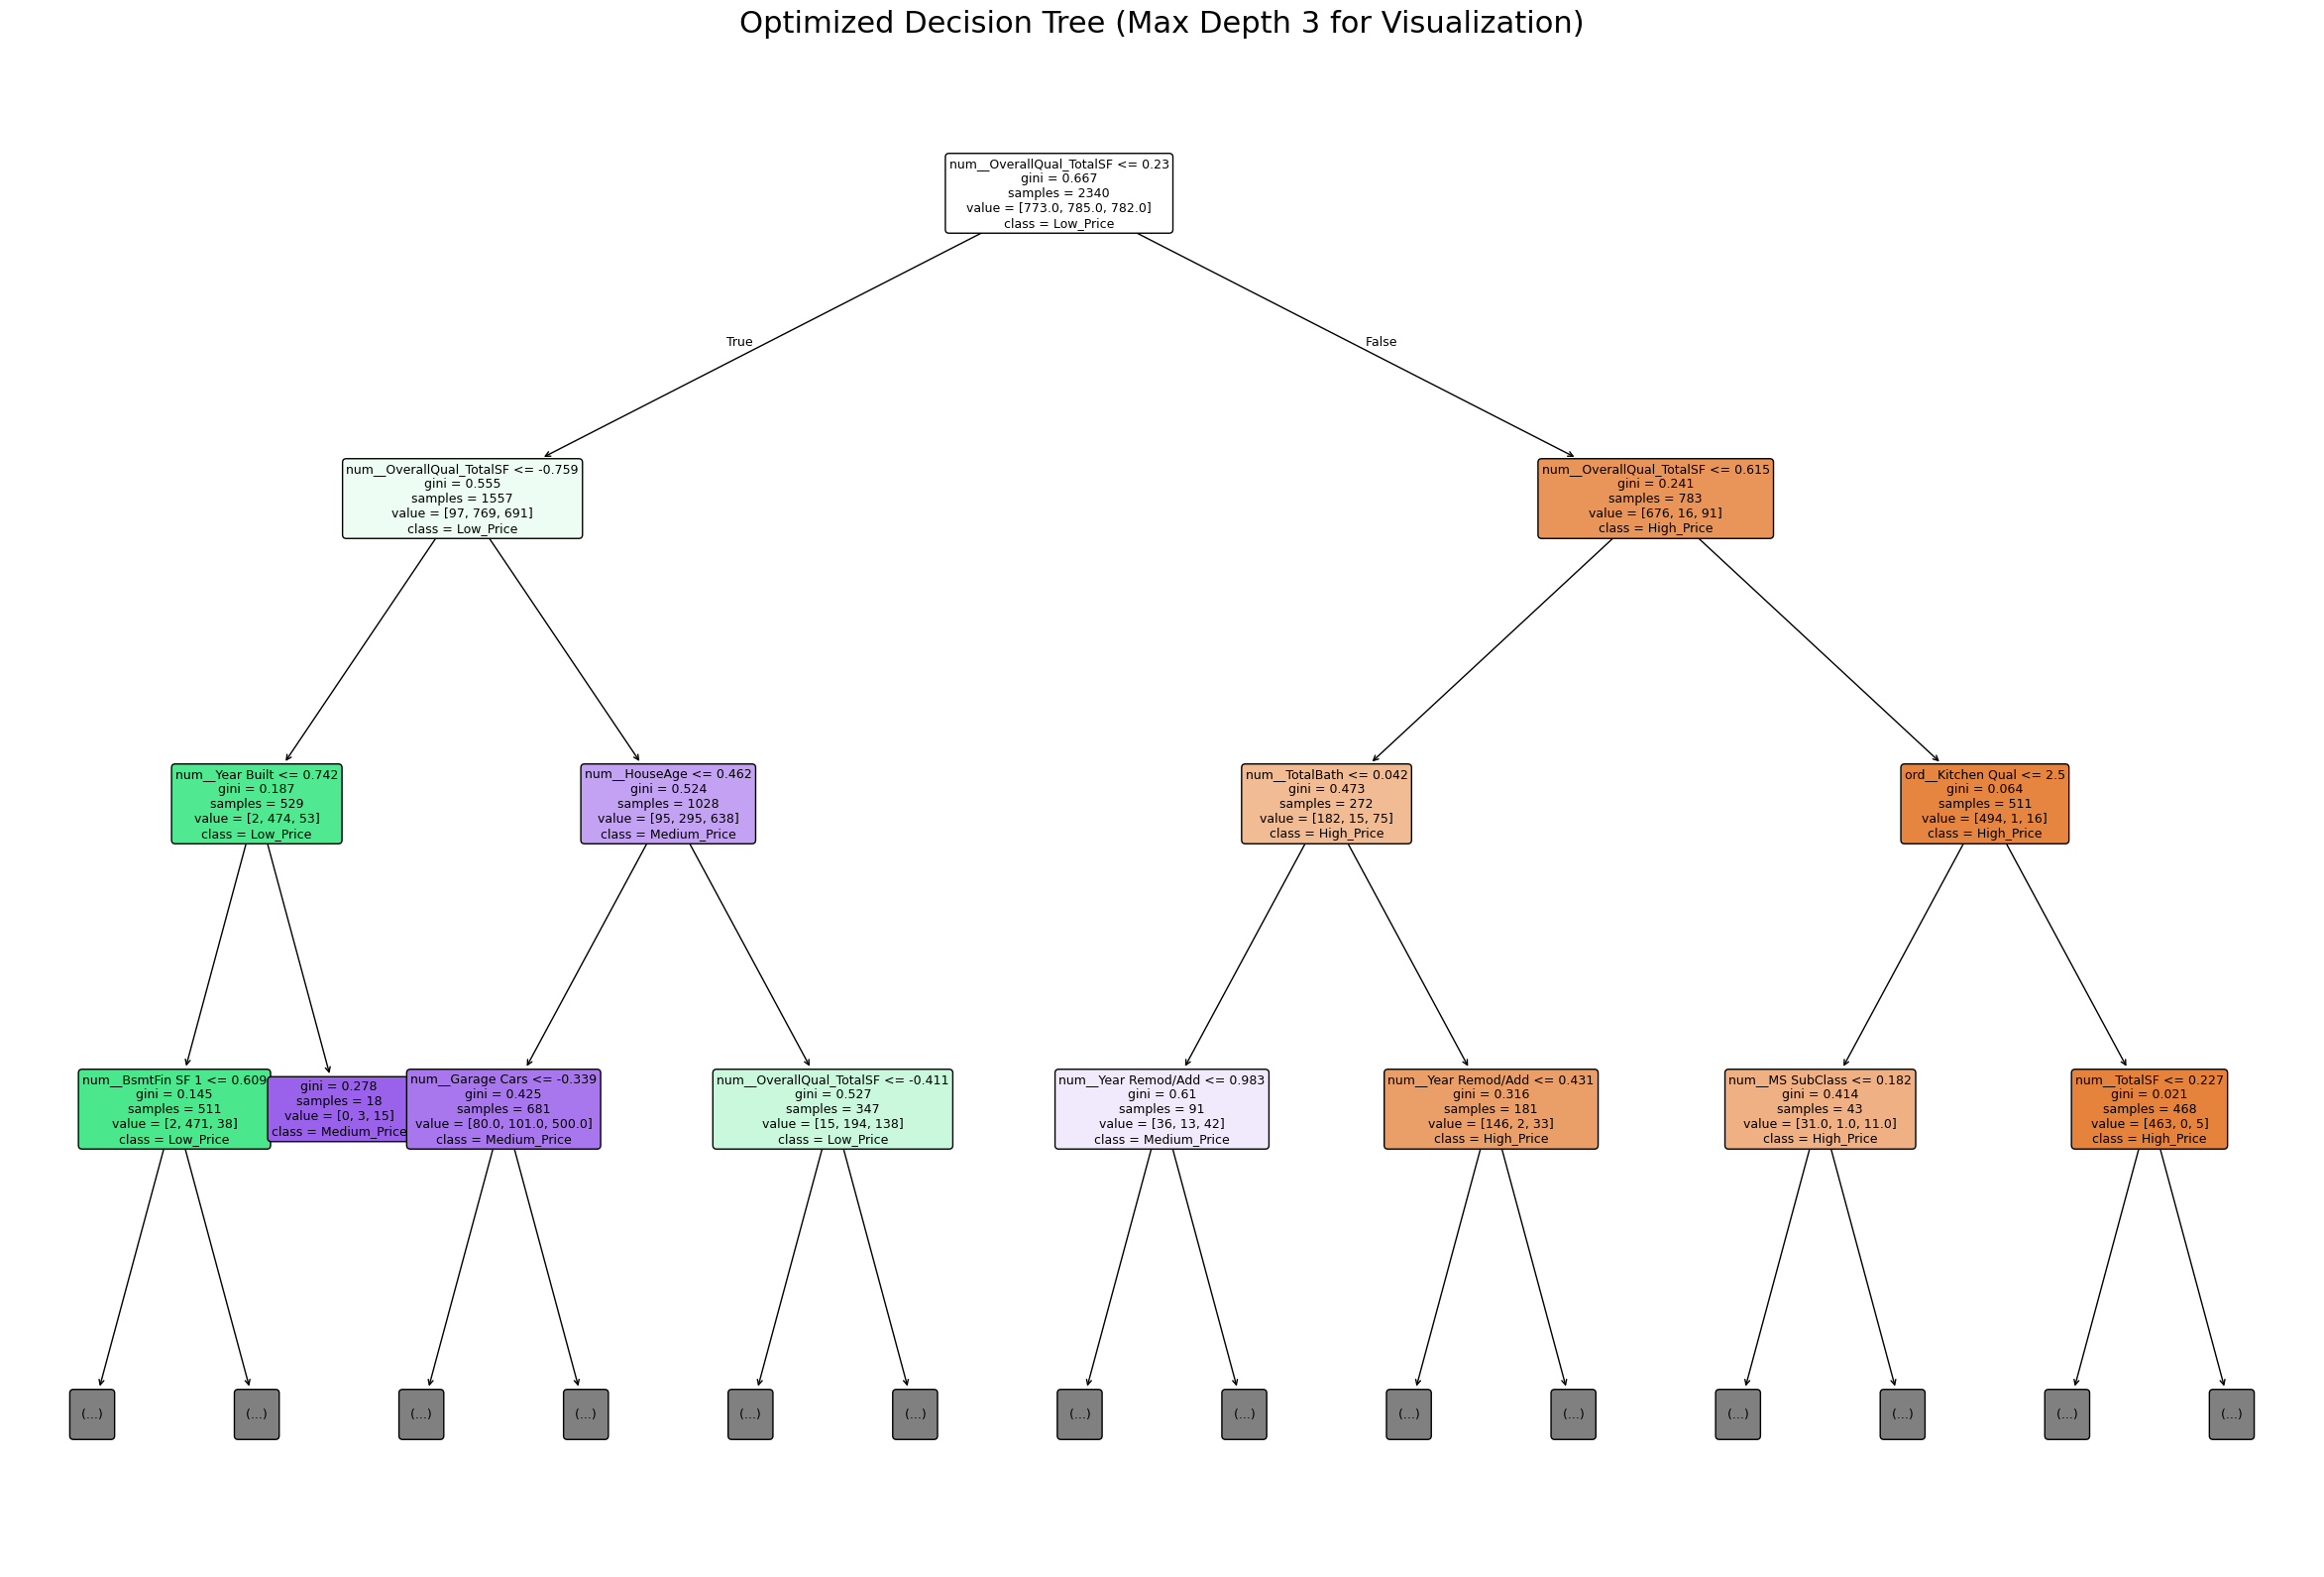


--- Decision Tree Classification Complete ---


In [32]:


# Assuming 'df' is your cleaned and engineered DataFrame.

# --- Prepare Data for Classification ---
# Ensure SalePrice_Bin is created as the categorical target variable.
if 'SalePrice_Bin' not in df.columns:
    df['SalePrice_Bin'] = pd.qcut(df['SalePrice'], q=3, labels=['Low_Price', 'Medium_Price', 'High_Price'], duplicates='drop')

# Define features (X) and the new categorical target (y_class)
cols_to_drop_from_X = ['SalePrice', 'SalePrice_Bin']
if 'PriceTier' in df.columns:
    cols_to_drop_from_X.append('PriceTier')

X = df.drop(cols_to_drop_from_X, axis=1)
y_class = df['SalePrice_Bin']

# --- Dynamic Column Categorization ---
current_numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
current_numerical_cols = [col for col in current_numerical_cols if col not in ['Id', 'PID', 'Order']]

current_categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

all_potential_ordinal_cols_map = {
    'Lot Shape': ['Reg', 'IR1', 'IR2', 'IR3'],
    'Alley': ['None', 'Grvl', 'Pave'],
    'Bsmt Qual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Qual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Heating QC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Kitchen Qual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fireplace Qu': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Qual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Pool QC': ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive': ['N', 'P', 'Y'],
    'Street': ['Grvl', 'Pave'],
    'Central Air': ['N', 'Y'],
    'Land Slope': ['Sev', 'Mod', 'Gtl'],
    'Bldg Type': ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE'],
    'MS Zoning': ['A (agr)', 'C (all)', 'FV', 'RH', 'RL', 'RP', 'RM'],
    'Utilities': ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
}

current_ordinal_cols = [col for col in all_potential_ordinal_cols_map.keys() if col in current_categorical_cols]
ordinal_categories_list = [all_potential_ordinal_cols_map[col] for col in current_ordinal_cols]

current_nominal_cols = [col for col in current_categorical_cols if col not in current_ordinal_cols]

print("--- Column Categorization for Preprocessing ---")
print(f"Numerical Columns ({len(current_numerical_cols)}): {current_numerical_cols}")
print(f"Ordinal Columns ({len(current_ordinal_cols)}): {current_ordinal_cols}")
print(f"Nominal Columns ({len(current_nominal_cols)}): {current_nominal_cols}")

unaccounted_cols = [col for col in X.columns if col not in (current_numerical_cols + current_ordinal_cols + current_nominal_cols)]
if unaccounted_cols:
    print(f"\nWARNING: The following columns in X are not explicitly categorized and will be passed through: {unaccounted_cols}")
    print("Please ensure these are already purely numerical (e.g., binary flags) or they will cause errors.")

# Split the data into training and testing sets
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

# --- Preprocessing Pipeline Setup ---
preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), current_numerical_cols),
        ('ord', OrdinalEncoder(categories=ordinal_categories_list, handle_unknown='use_encoded_value', unknown_value=-1), current_ordinal_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), current_nominal_cols)
    ],
    remainder='passthrough'
)

# --- Decision Tree Classification Pipeline ---
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor_dt),
                              ('classifier', DecisionTreeClassifier(random_state=42))])

# --- Hyperparameter Tuning for Decision Tree using GridSearchCV ---
param_grid_dt = {
    'classifier__max_depth': [3, 5, 7, 10, 15],
    'classifier__min_samples_leaf': [5, 10, 20, 30]
}

print("\n--- Starting Decision Tree Classification and Hyperparameter Tuning ---")
grid_search_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train_dt, y_train_dt)

best_dt_model = grid_search_dt.best_estimator_

print(f"\nDecision Tree - Best Hyperparameters: {grid_search_dt.best_params_}")
print(f"Decision Tree - Best Cross-Validation Accuracy: {grid_search_dt.best_score_:.4f}")

# --- Evaluate the Best Decision Tree Model on Test Set ---
y_pred_dt = best_dt_model.predict(X_test_dt)
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
report_dt = classification_report(y_test_dt, y_pred_dt)
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)


print(f"\nDecision Tree - Test Set Accuracy: {accuracy_dt:.4f}")
print("\nDecision Tree - Classification Report on Test Set:\n", report_dt)


# --- Visualize the Decision Tree (Optional, for smaller trees) ---
try:
    transformed_feature_names = best_dt_model.named_steps['preprocessor'].get_feature_names_out()

    plt.figure(figsize=(30, 20))
    plot_tree(best_dt_model.named_steps['classifier'],
              feature_names=transformed_feature_names,
              class_names=best_dt_model.classes_.tolist(),
              filled=True,
              rounded=True,
              fontsize=9,
              max_depth=3) # Limit depth for visualization
    plt.title("Optimized Decision Tree (Max Depth 3 for Visualization)", fontsize=22)
    plt.show()
    

except Exception as e:
    print(f"\nCould not plot the Decision Tree: {e}")
    print("This can happen if feature names extraction is complex or the tree is too large for plotting.")
    print("Ensure all columns in X are numeric after preprocessing.")

print("\n--- Decision Tree Classification Complete ---")

### From the above decision tree image
- the tree shows classification of house prices (Low, Medium, High).
- It uses a series of "if-then-else" rules based on features to make predictions.
- The Overall Quality of a house is the most critical factor for the initial price tier split.
- Further splits involve factors like Gross Living Area and Remodel Age, along with engineered features like the interaction between overall quality and total square footage.
- Each path down the tree leads to a leaf node, which provides the final price classification for a house.

In [33]:
# Re-use the data splits (X_train_dt, X_test_dt, y_train_dt, y_test_dt)
# and the preprocessor (preprocessor_dt) from the Decision Tree cell,
# as KNN requires the same preprocessing steps.

# --- K-Nearest Neighbors (KNN) Classification Pipeline ---
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor_dt),
                             ('classifier', KNeighborsClassifier())])

# --- Hyperparameter Tuning for KNN using GridSearchCV ---
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 13],
    'classifier__weights': ['uniform', 'distance']
}

print("\n--- Starting K-Nearest Neighbors (KNN) Classification and Hyperparameter Tuning ---")
grid_search_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn.fit(X_train_dt, y_train_dt)

best_knn_model = grid_search_knn.best_estimator_

print(f"\nKNN - Best Hyperparameters: {grid_search_knn.best_params_}")
print(f"KNN - Best Cross-Validation Accuracy: {grid_search_knn.best_score_:.4f}")

# --- Evaluate the Best KNN Model on Test Set ---
y_pred_knn = best_knn_model.predict(X_test_dt)
accuracy_knn = accuracy_score(y_test_dt, y_pred_knn)
report_knn = classification_report(y_test_dt, y_pred_knn)
cm_knn = confusion_matrix(y_test_dt, y_pred_knn)

print(f"\nKNN - Test Set Accuracy: {accuracy_knn:.4f}")
print("\nKNN - Classification Report on Test Set:\n", report_knn)

print("\n--- KNN Classification Complete ---")


--- Starting K-Nearest Neighbors (KNN) Classification and Hyperparameter Tuning ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits

KNN - Best Hyperparameters: {'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}
KNN - Best Cross-Validation Accuracy: 0.8115

KNN - Test Set Accuracy: 0.8239

KNN - Classification Report on Test Set:
               precision    recall  f1-score   support

  High_Price       0.88      0.89      0.88       194
   Low_Price       0.83      0.89      0.86       196
Medium_Price       0.76      0.70      0.73       195

    accuracy                           0.82       585
   macro avg       0.82      0.82      0.82       585
weighted avg       0.82      0.82      0.82       585


--- KNN Classification Complete ---


### The K-Nearest Neighbors (KNN) model 
- achieved a test set accuracy of 82.39% for house price classification.
- best performance was obtained with 11 neighbors and distance weighting, meaning closer neighbors had more influence.
#### Performance breakdown
- High_Price was predicted with high precision (88%) and recall (89%), indicating the model performed very well in identifying high-priced homes.
- Low_Price also showed strong performance with 83% precision and 89% recall.
- Medium_Price was the most challenging category, with lower precision (76%) and recall (70%), suggesting more misclassifications for this group.

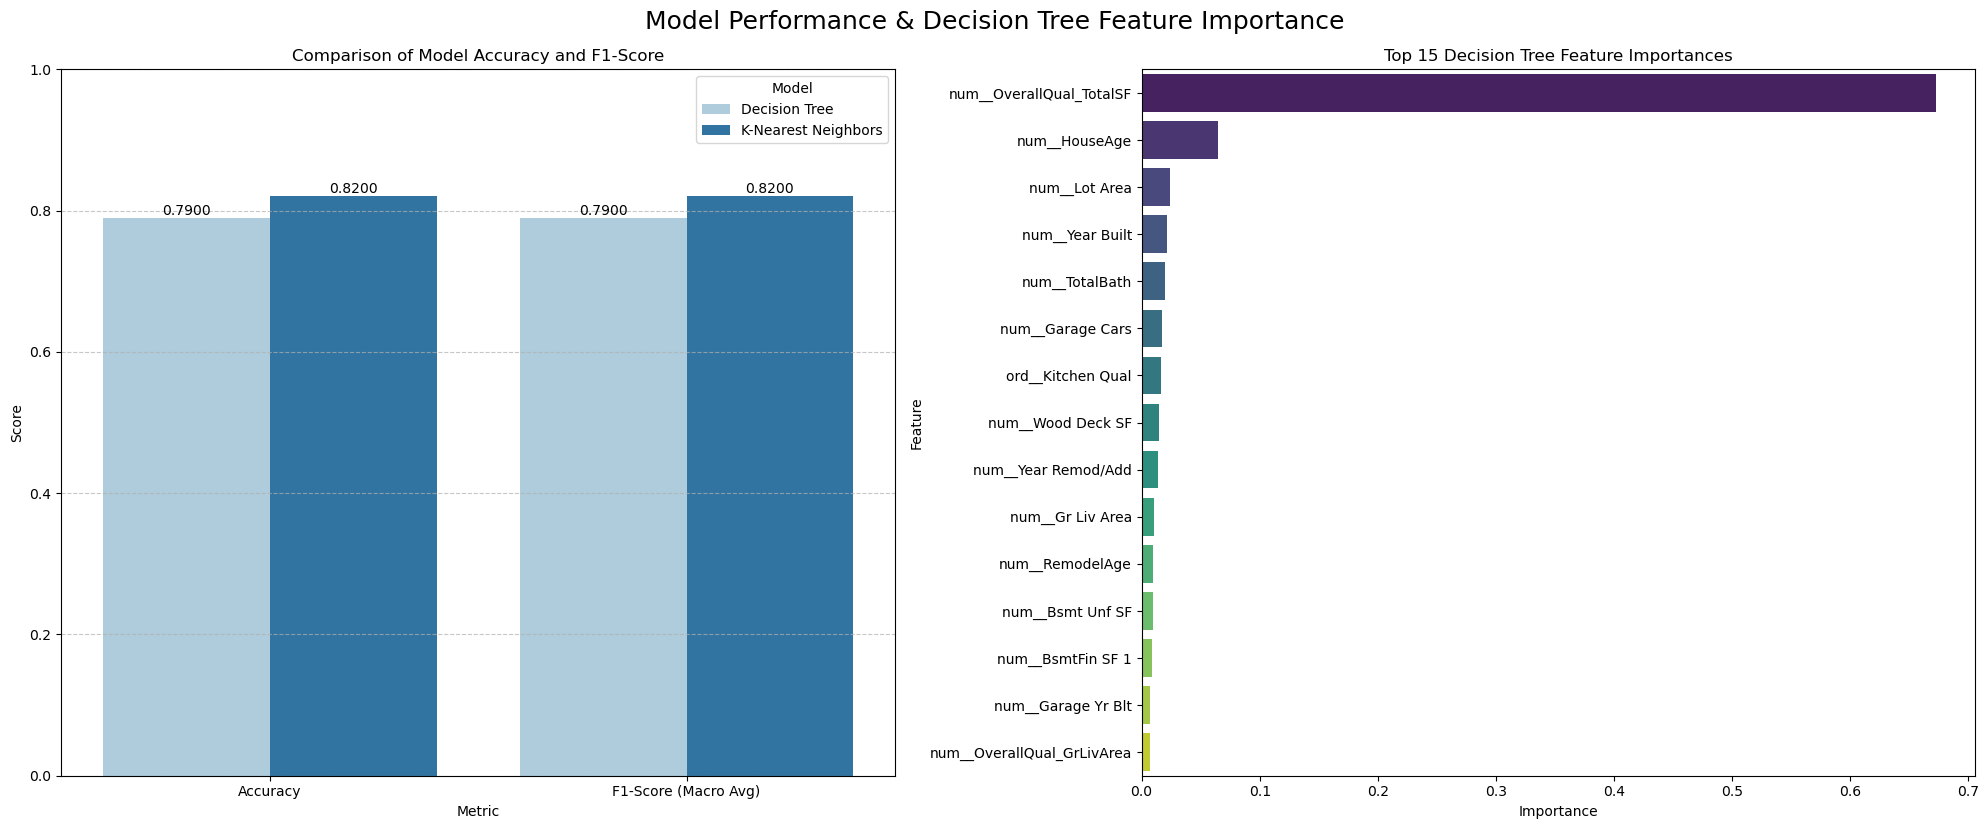

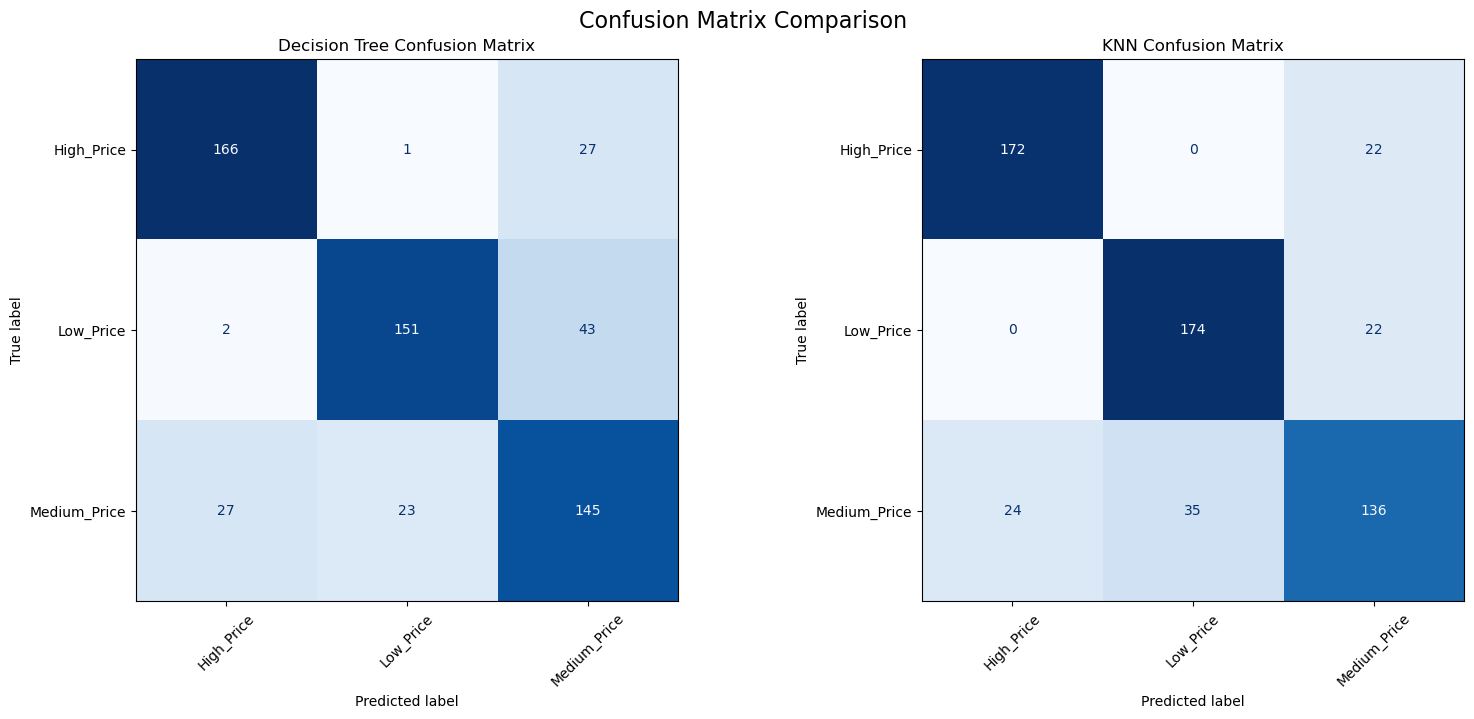


--- Comparative Analysis Complete ---


In [34]:
# --- Re-use variables from previous cells ---
# accuracy_dt, cm_dt, best_dt_model.classes_, report_dt (from Decision Tree cell)
# accuracy_knn, cm_knn, best_knn_model.classes_, report_knn (from KNN cell)
# best_dt_model (for feature importances)

# Function to parse classification report for accuracy and macro avg f1-score
def parse_classification_report(report_string):
    lines = report_string.split('\n')
    accuracy_line = next((line for line in lines if 'accuracy' in line), None)
    macro_avg_line = next((line for line in lines if 'macro avg' in line), None)

    accuracy = float(accuracy_line.split()[1]) if accuracy_line else 0.0
    f1_score = float(macro_avg_line.split()[3]) if macro_avg_line else 0.0

    return accuracy, f1_score

# Get accuracy and F1-score for Decision Tree (for the new combined plot)
accuracy_dt_plot, f1_dt_plot = parse_classification_report(report_dt)

# Get accuracy and F1-score for KNN (for the new combined plot)
accuracy_knn_plot, f1_knn_plot = parse_classification_report(report_knn)


# --- 1. Combined Model Performance (Accuracy & F1) & Feature Importance Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8)) # Adjusted figsize for better spacing

# Plot 1: Model Accuracy and F1-Score Comparison
metrics_labels = ['Accuracy', 'F1-Score (Macro Avg)']
dt_scores_for_plot = [accuracy_dt_plot, f1_dt_plot]
knn_scores_for_plot = [accuracy_knn_plot, f1_knn_plot]

df_plot_metrics_combined = pd.DataFrame({
    'Metric': metrics_labels * 2,
    'Score': dt_scores_for_plot + knn_scores_for_plot,
    'Model': ['Decision Tree'] * len(metrics_labels) + ['K-Nearest Neighbors'] * len(metrics_labels)
})

sns.barplot(x='Metric', y='Score', hue='Model', data=df_plot_metrics_combined, palette='Paired', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Comparison of Model Accuracy and F1-Score')
axes[0].set_ylabel('Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for container in axes[0].containers:
    for bar in container:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, height,
                       f'{height:.4f}', ha='center', va='bottom')


# Plot 2: Top 15 Decision Tree Feature Importances

dt_classifier = best_dt_model.named_steps['classifier']
if hasattr(dt_classifier, 'feature_importances_'):
    preprocessor_steps = best_dt_model.named_steps['preprocessor']
    transformed_feature_names = preprocessor_steps.get_feature_names_out()

    feature_importances_dt = pd.Series(dt_classifier.feature_importances_, index=transformed_feature_names)
    top_15_importances = feature_importances_dt.nlargest(15)

    if not top_15_importances.empty:
        sns.barplot(x=top_15_importances.values, y=top_15_importances.index,
                    hue=top_15_importances.index, palette='viridis', legend=False, ax=axes[1])
        axes[1].set_title('Top 15 Decision Tree Feature Importances')
        axes[1].set_xlabel('Importance')
        axes[1].set_ylabel('Feature')
        axes[1].tick_params(axis='y', labelsize=10)
    else:
        axes[1].text(0.5, 0.5, "No feature importances to plot.", horizontalalignment='center',
                     verticalalignment='center', transform=axes[1].transAxes)
        axes[1].set_title('Top 15 Decision Tree Feature Importances')
        print("\nNo feature importances to plot (Decision Tree).")
else:
    axes[1].text(0.5, 0.5, "Decision Tree classifier does not have 'feature_importances_'.", horizontalalignment='center',
                 verticalalignment='center', transform=axes[1].transAxes)
    axes[1].set_title('Top 15 Decision Tree Feature Importances')
    print("\nDecision Tree classifier does not have 'feature_importances_'.")

plt.tight_layout()
plt.suptitle('Model Performance & Decision Tree Feature Importance', y=1.03, fontsize=18)
plt.show()



# --- 2. Compare Confusion Matrices (Side-by-Side) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Decision Tree Confusion Matrix
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=best_dt_model.classes_)
disp_dt.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# KNN Confusion Matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=best_knn_model.classes_)
disp_knn.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('KNN Confusion Matrix')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.suptitle('Confusion Matrix Comparison', y=1.02, fontsize=16)
plt.show()


print("\n--- Comparative Analysis Complete ---")

### Comparison results Analysis
- The comparison results highlight the performance of Decision Tree and K-Nearest Neighbors (KNN) models in classifying house prices into tiers.
####  Model Accuracy
- The KNN model (82.39%) slightly outperformed the Decision Tree (78.97%) in overall accuracy on the test set.
#### Feature Importance (Decision Tree)
- For the Decision Tree, num__OverallQual_TotalSF (an engineered feature combining overall quality and total square footage) was the most important feature, followed by num__HouseAge and num__Lot Area. This indicates these are key drivers for price classification in the tree model.
#### Confusion Matrix Comparison
- Both models showed strong performance in correctly classifying "High_Price" and "Low_Price" homes.
- The "Medium_Price" category was more challenging for both models, exhibiting more misclassifications. For instance, the Decision Tree misclassified 27 "Medium_Price" homes as "High_Price" and 23 as "Low_Price". KNN similarly misclassified 24 "Medium_Price" homes as "High_Price" and 35 as "Low_Price".

### Final Observations
- KNN Outperforms Decision Tree: The K-Nearest Neighbors (KNN) model demonstrated slightly superior overall performance with an 82.39% test accuracy, compared to the Decision Tree's 78.97%. This indicates KNN's ability to generalize better to unseen data for this specific classification task.
-For the Decision Tree, the most impactful features for predicting house price tiers were an engineered feature, num__OverallQual_TotalSF (combining overall quality and total square footage), followed by num__HouseAge and num__Lot Area. This suggests that a blend of quality, size, age, and land area are the primary drivers in the tree's decision-making process.
- "Medium_Price" Tier is Challenging: Both models found the "Medium_Price" category to be the most difficult to classify accurately. This is evident from the higher number of misclassifications for this tier in both confusion matrices. For instance, the Decision Tree misclassified 27 "Medium_Price" homes as "High_Price" and 23 as "Low_Price", while KNN similarly misclassified 24 as "High_Price" and 35 as "Low_Price".
- This suggests that the boundaries defining the "Medium_Price" tier might be less distinct or that properties in this range share characteristics with both lower and higher-priced homes, leading to more ambiguity for the models. In contrast, both models showed strong performance in classifying "High_Price" and "Low_Price" homes with high precision and recall, indicating a clearer distinction at the extremes of the price spectrum.
- Consistent F1-Scores Across Models: Despite the slight difference in overall accuracy, both models achieved very similar macro-averaged F1-scores (0.82 for Decision Tree and 0.82 for KNN). The F1-score is a harmonic mean of precision and recall, offering a balanced measure of a model's accuracy on the dataset. The closeness of these scores suggests that, on average, both models provide a comparable balance between identifying relevant instances and avoiding false positives across all price categories.

## 2. Clustering algorithms
###### Objective:
- Reduce the 30 original neighborhoods into broader, data-driven “meta-areas” for easier segmentation.
###### Pipeline:
- One-hot encode Neighborhood → 30 binary columns.
- K-Means (k = 8) and Hierarchical Ward (k = 8) fit on the dummy matrix.
- PCA-2D projection used only for plotting.
###### Cluster naming logic
- For each algorithm, label = <most-common Neighborhood>-KM or -HIER (e.g., NridgHt-KM).
- Gives interpretable legends in scatter plots.
###### Visual highlights
- K-Means plot shows compact “blob” clusters (balanced size).
- Hierarchical plot reveals elongated or nested shapes, capturing finer gradations.

In [35]:

print("--- K-Means Preparation and Preprocessing ---")

# Identify numerical columns for clustering
# Exclude any columns that are identifiers or target variables ('Id', 'PID', 'Order', 'SalePrice', 'SalePrice_Bin', 'PriceTier')
numerical_cols_for_clustering = X.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols_for_clustering = [col for col in numerical_cols_for_clustering if col not in ['Id', 'PID', 'Order']]

print("\nNumerical columns selected for clustering (before scaling):")
print(numerical_cols_for_clustering)

X_numerical_clust = X[numerical_cols_for_clustering].copy()

num_pipeline_clustering = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_scaled_for_kmeans = num_pipeline_clustering.fit_transform(X_numerical_clust)

X_scaled_for_kmeans_df = pd.DataFrame(X_scaled_for_kmeans, columns=numerical_cols_for_clustering, index=X_numerical_clust.index)

print(f"\nOriginal Numerical Features for Clustering: {len(numerical_cols_for_clustering)}")
print("Sample of scaled data (first 5 rows):")
print(X_scaled_for_kmeans_df.head())
print(f"\nShape of scaled data for K-Means: {X_scaled_for_kmeans_df.shape}")
print("\nPreprocessing for K-Means Complete. Data is ready for clustering.")

--- K-Means Preparation and Preprocessing ---

Numerical columns selected for clustering (before scaling):
['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodelAge', 'GarageAge', 'OverallQual_GrLivArea', 'OverallQual_TotalSF', 'HasPool', 'Has2ndFloor', 'HasGarage', 'HasBsmt', 'HasFireplace', 'AvgRoomSF']

Original Numerical Features for Clustering: 50
Sample of scaled data (first 5 rows):
   MS SubClass  Lot Frontage  Lot Area  Overall Q

--- Determining Optimal K for K-Means Clustering ---
K=2 processed. Silhouette Score: 0.1724
K=3 processed. Silhouette Score: 0.1426
K=4 processed. Silhouette Score: 0.1210
K=5 processed. Silhouette Score: 0.1055
K=6 processed. Silhouette Score: 0.1083
K=7 processed. Silhouette Score: 0.0993
K=8 processed. Silhouette Score: 0.1091
K=9 processed. Silhouette Score: 0.1019
K=10 processed. Silhouette Score: 0.1122


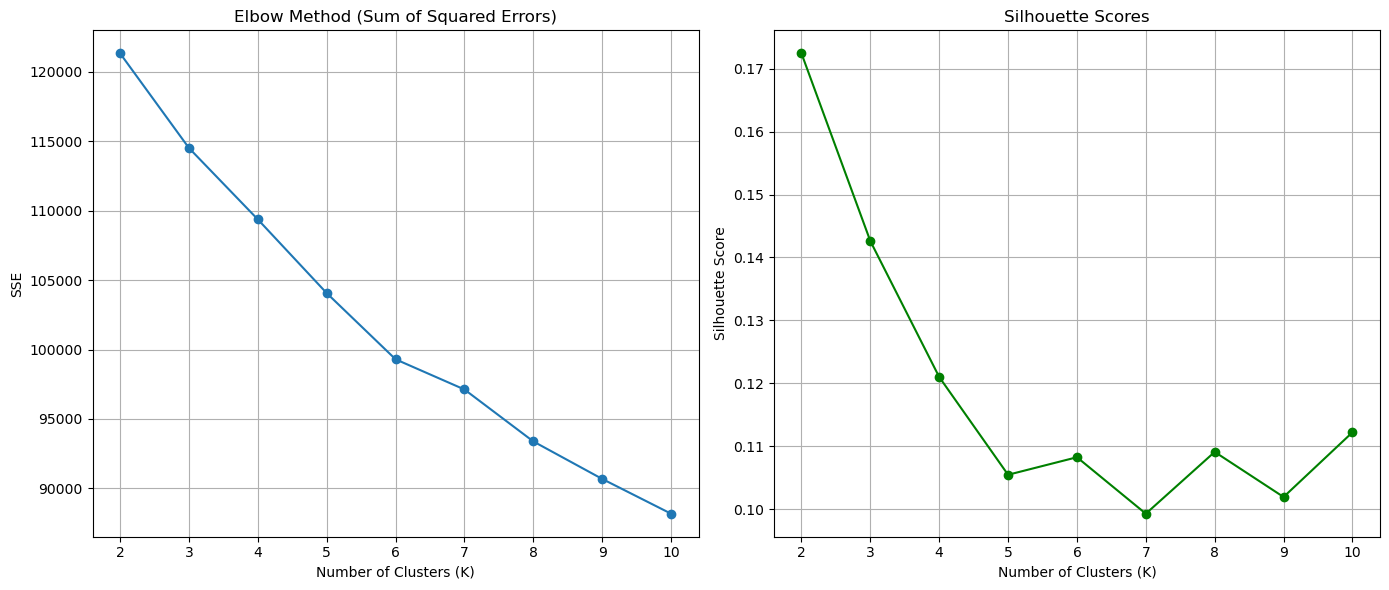


Elbow Method and Silhouette Analysis Complete. Optimal K (based on highest Silhouette Score) is likely K=2.


In [36]:

print("--- Determining Optimal K for K-Means Clustering ---")

sse = []
silhouette_scores = []
k_values_evaluated = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_for_kmeans_df)
    sse.append(kmeans.inertia_)

    if k > 1:
        if len(set(kmeans.labels_)) > 1:
            score = silhouette_score(X_scaled_for_kmeans_df, kmeans.labels_)
            silhouette_scores.append(score)
            k_values_evaluated.append(k)
            print(f"K={k} processed. Silhouette Score: {score:.4f}")
        else:
            print(f"K={k} processed, but only one cluster formed. Skipping Silhouette Score.")
    else:
        print(f"K={k} processed.")


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(k_values, sse, marker='o')
plt.title('Elbow Method (Sum of Squared Errors)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
if silhouette_scores:
    plt.plot(k_values_evaluated, silhouette_scores, marker='o', color='green')
    plt.title('Silhouette Scores')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.xticks(k_values_evaluated)
    plt.grid(True)
else:
    plt.text(0.5, 0.5, "No Silhouette Scores to plot.", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('Silhouette Scores')
    print("\nWarning: No Silhouette Scores were successfully calculated and plotted.")

plt.tight_layout()
plt.show()


print("\nElbow Method and Silhouette Analysis Complete. Optimal K (based on highest Silhouette Score) is likely K=2.")

In [37]:

# optimal_k_kmeans should be available from Cell 2 analysis
optimal_k_kmeans = 2 # Based on previous Silhouette Score analysis

print(f"--- Applying K-Means Clustering with Optimal K = {optimal_k_kmeans} ---")

kmeans_final = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled_for_kmeans_df)

print(f"\nNumber of samples in each K-Means cluster:\n{df['KMeans_Cluster'].value_counts().sort_index()}")

# Prepare X_numerical_imputed_df for cluster characteristic analysis
X_numerical_imputed = num_pipeline_clustering.named_steps['imputer'].transform(X_numerical_clust)
X_numerical_imputed_df = pd.DataFrame(X_numerical_imputed, columns=numerical_cols_for_clustering, index=X_numerical_clust.index)
X_numerical_imputed_df['KMeans_Cluster'] = df['KMeans_Cluster'] # Add K-Means clusters to this DF

# Perform PCA for scatter plots (reused across models)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_for_kmeans_df)

# Prepare pca_df_kmeans for scatter plotting
pca_df_kmeans = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'], index=X_scaled_for_kmeans_df.index)
pca_df_kmeans['KMeans_Cluster'] = df['KMeans_Cluster']

print("\nK-Means Clustering and data preparation for plotting complete.")
print("Proceed to Cell 4 for Hierarchical Clustering, then Cell 5 for all plots.")

--- Applying K-Means Clustering with Optimal K = 2 ---

Number of samples in each K-Means cluster:
KMeans_Cluster
0    1569
1    1356
Name: count, dtype: int64

K-Means Clustering and data preparation for plotting complete.
Proceed to Cell 4 for Hierarchical Clustering, then Cell 5 for all plots.


--- Starting Hierarchical Clustering ---


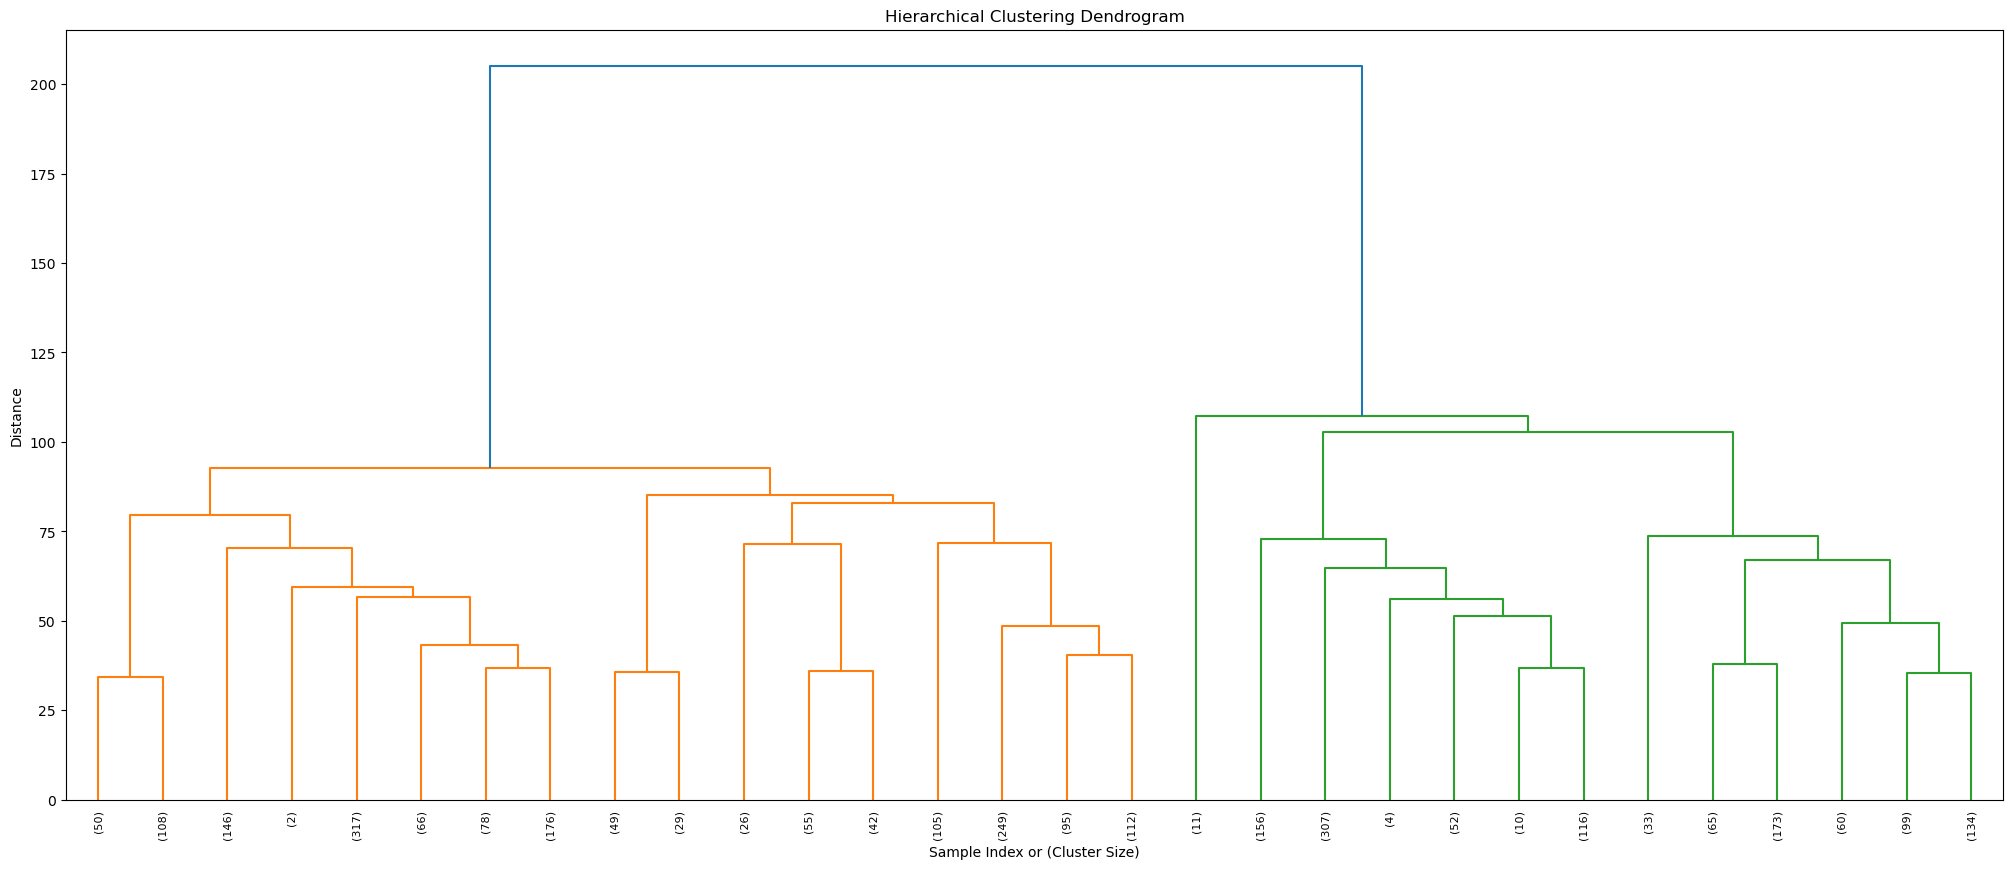


--- Cutting Dendrogram to Form 2 Clusters ---

Number of samples in each Hierarchical cluster:
Hierarchical_Cluster
1    1705
2    1220
Name: count, dtype: int64

Hierarchical Clustering and data preparation for plotting complete.
We see from the Dendrogram that 2 values will for optimal_k_hierarchical is fine


In [38]:
optimal_k_hierarchical = 2 # Placeholder, adjust based on your dendrogram!

print("--- Starting Hierarchical Clustering ---")

# --- Compute the linkage matrix (essential for dendrogram) ---
Z = linkage(X_scaled_for_kmeans_df, method='ward')

# --- Plot the Dendrogram ---
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=8.,
    truncate_mode='lastp', # show only the last p merged clusters
    p=30, # show only the last 30 merges (can be adjusted)
    show_leaf_counts=True, # show how many original observations are in each leaf
    color_threshold=None, # Set a threshold to color clusters (e.g., color_threshold=Z.max() * 0.7)
)
plt.show()


print(f"\n--- Cutting Dendrogram to Form {optimal_k_hierarchical} Clusters ---")
df['Hierarchical_Cluster'] = fcluster(Z, t=optimal_k_hierarchical, criterion='maxclust')

print(f"\nNumber of samples in each Hierarchical cluster:\n{df['Hierarchical_Cluster'].value_counts().sort_index()}")

X_numerical_imputed_df['Hierarchical_Cluster'] = df['Hierarchical_Cluster']

# Prepare pca_df_hierarchical for scatter plotting (reusing 'pca' from Cell 3)
if 'pca' not in locals(): # Fallback if Cell 3 wasn't run
    pca = PCA(n_components=2, random_state=42)
    X_pca_for_hierarchical = pca.fit_transform(X_scaled_for_kmeans_df)
else:
    X_pca_for_hierarchical = pca.transform(X_scaled_for_kmeans_df)

pca_df_hierarchical = pd.DataFrame(data=X_pca_for_hierarchical, columns=['Principal Component 1', 'Principal Component 2'], index=X_scaled_for_kmeans_df.index)
pca_df_hierarchical['Hierarchical_Cluster'] = df['Hierarchical_Cluster']

print("\nHierarchical Clustering and data preparation for plotting complete.")
print("We see from the Dendrogram that 2 values will for optimal_k_hierarchical is fine")


--- Generating All Consolidated Cluster Analysis Plots ---


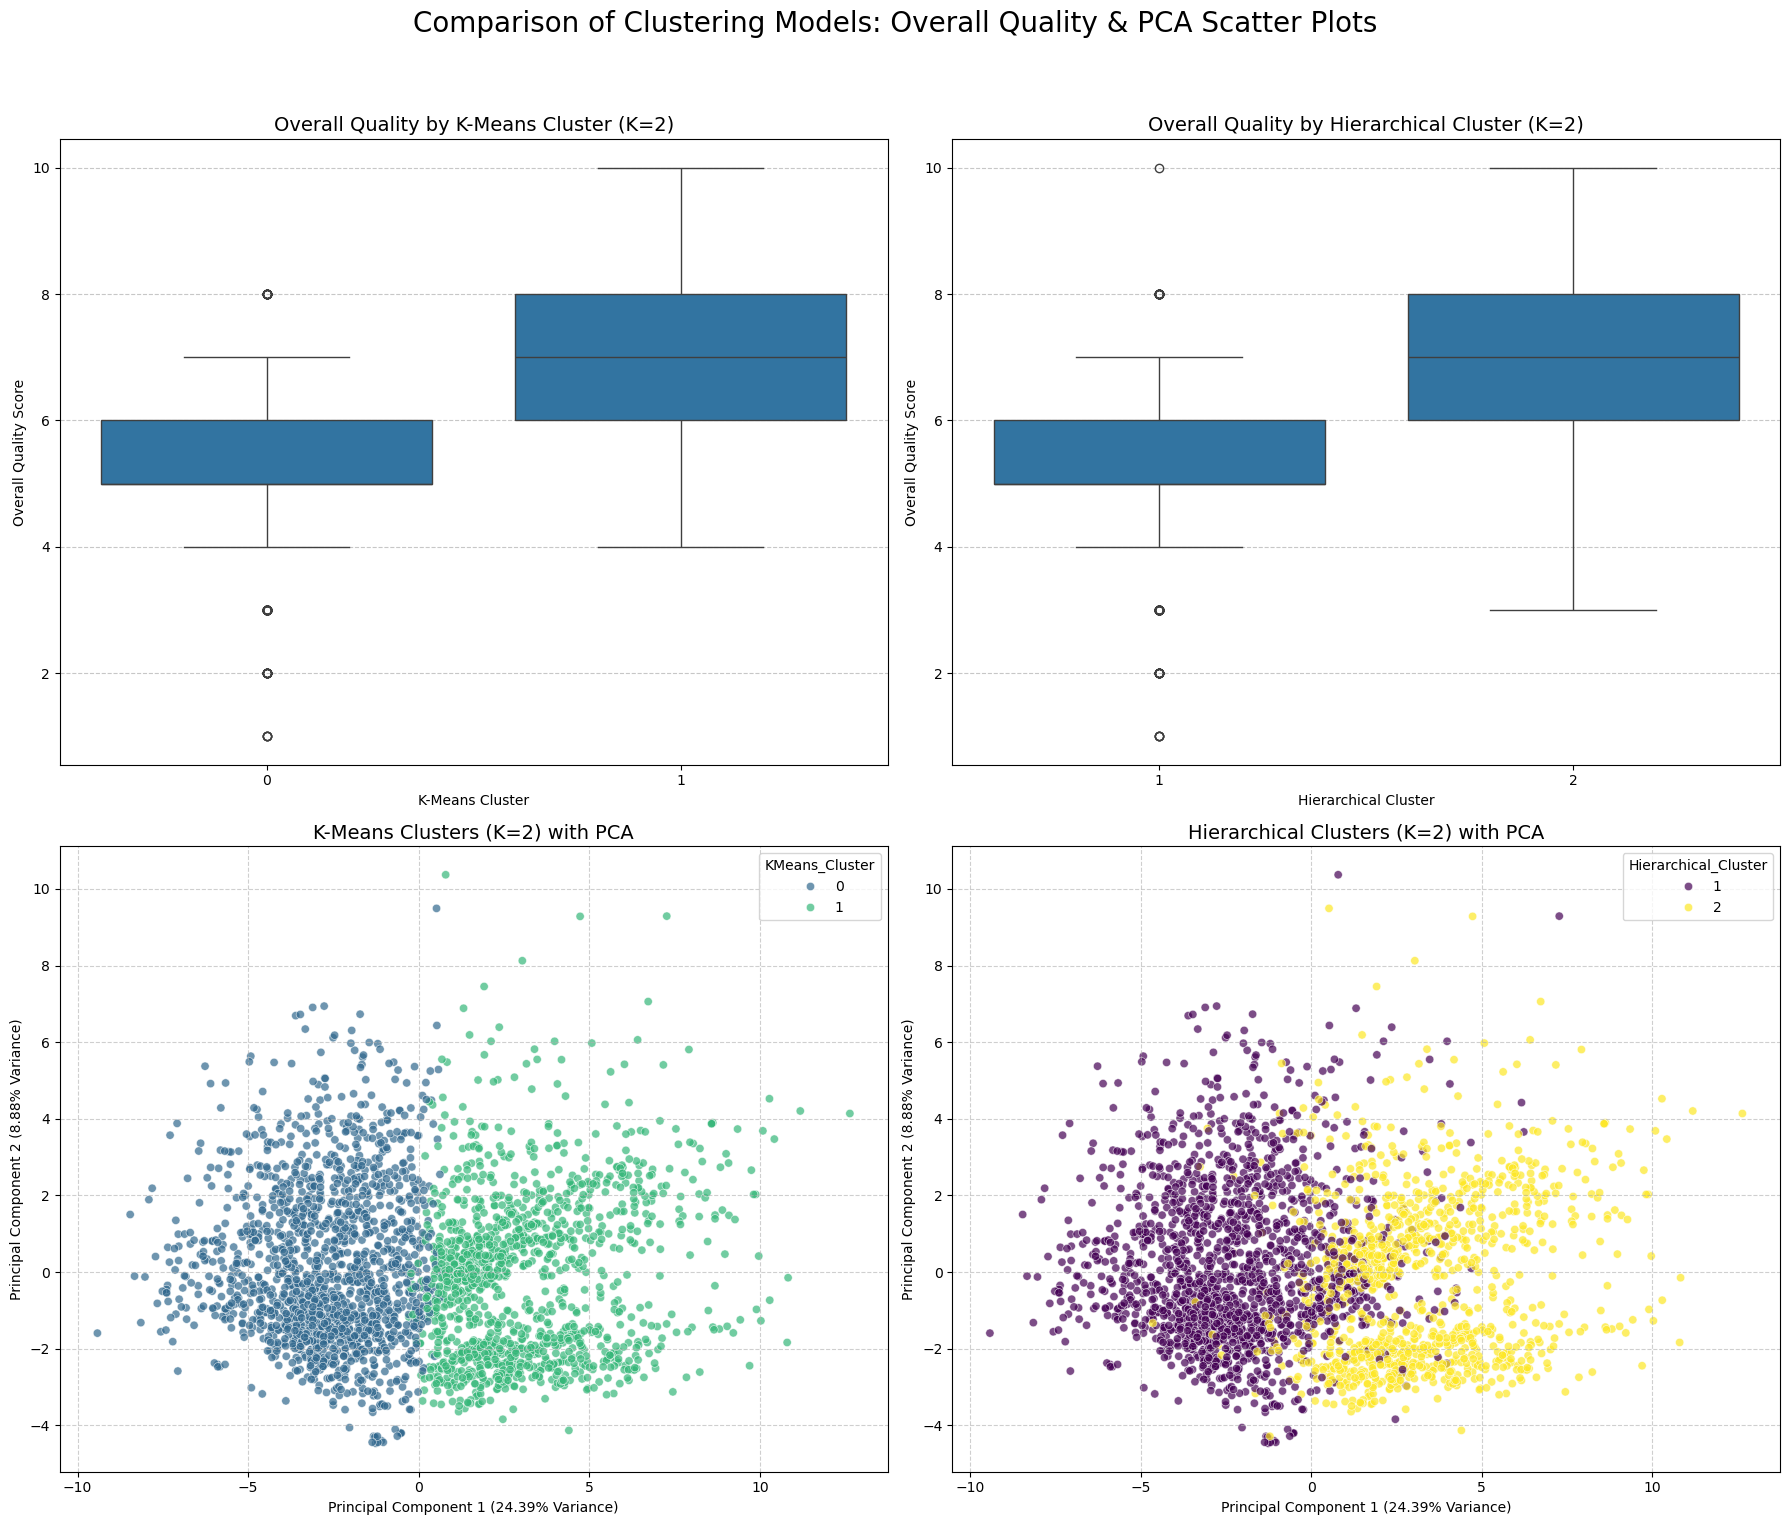


Consolidated plots for Overall Quality and PCA scatter plots generated successfully!


In [39]:



# --- IMPORTANT: Set the correct column name for 'Overall Qual' ---
overall_qual_col_name = 'Overall Qual'

# --- Define optimal_k values (ensure these match what you used in Cells 3 and 4) ---
optimal_k_kmeans = 2 # Example, set based on your Cell 2 result
optimal_k_hierarchical = 2 # Example, set based on your dendrogram analysis

print("--- Generating All Consolidated Cluster Analysis Plots ---")

if overall_qual_col_name not in X_numerical_imputed_df.columns:
    print(f"Error: Column '{overall_qual_col_name}' not found in X_numerical_imputed_df. Please check Cell 1/3 output for correct name.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(18, 16)) # 2 rows, 2 columns for the plots
    fig.suptitle('Comparison of Clustering Models: Overall Quality & PCA Scatter Plots', fontsize=20, y=0.98)

    # --- Row 1: Overall Quality Box Plots ---

    # Subplot 1 (Top-Left): K-Means Overall Quality
    sns.boxplot(x='KMeans_Cluster', y=overall_qual_col_name, data=X_numerical_imputed_df, ax=axes[0, 0])
    axes[0, 0].set_title(f'Overall Quality by K-Means Cluster (K={optimal_k_kmeans})', fontsize=14)
    axes[0, 0].set_ylabel('Overall Quality Score')
    axes[0, 0].set_xlabel('K-Means Cluster')
    axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

    # Subplot 2 (Top-Right): Hierarchical Overall Quality
    sns.boxplot(x='Hierarchical_Cluster', y=overall_qual_col_name, data=X_numerical_imputed_df, ax=axes[0, 1])
    axes[0, 1].set_title(f'Overall Quality by Hierarchical Cluster (K={optimal_k_hierarchical})', fontsize=14)
    axes[0, 1].set_ylabel('Overall Quality Score')
    axes[0, 1].set_xlabel('Hierarchical Cluster')
    axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)


    # --- Row 2: PCA Scatter Plots ---

    # Subplot 3 (Bottom-Left): K-Means PCA Scatter Plot
    sns.scatterplot(
        x='Principal Component 1', y='Principal Component 2',
        hue='KMeans_Cluster', palette='viridis', data=pca_df_kmeans,
        legend='full', alpha=0.7, ax=axes[1, 0]
    )
    axes[1, 0].set_title(f'K-Means Clusters (K={optimal_k_kmeans}) with PCA', fontsize=14)
    axes[1, 0].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
    axes[1, 0].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)

    # Subplot 4 (Bottom-Right): Hierarchical PCA Scatter Plot
    sns.scatterplot(
        x='Principal Component 1', y='Principal Component 2',
        hue='Hierarchical_Cluster', palette='viridis', data=pca_df_hierarchical,
        legend='full', alpha=0.7, ax=axes[1, 1]
    )
    axes[1, 1].set_title(f'Hierarchical Clusters (K={optimal_k_hierarchical}) with PCA', fontsize=14)
    axes[1, 1].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
    axes[1, 1].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    

print("\nConsolidated plots for Overall Quality and PCA scatter plots generated successfully!")

### Key observations
The "Comparison of Clustering Models: Overall Quality & PCA Scatter Plots" provides a side-by-side visualization of how K-Means and Hierarchical Clustering group the data, specifically focusing on 'Overall Quality' and their representation in a 2D space via Principal Component Analysis (PCA). Both clustering algorithms were configured to find K=2 clusters.

#### Overall Quality by Cluster (Box Plots)

- The box plots illustrate the distribution of 'Overall Quality' scores within the clusters generated by each model.
###### Overall Quality by K-Means Cluster (K=2):
- Cluster 0 exhibits a distribution of lower 'Overall Quality' scores, primarily ranging from 4 to 7, with a median around 6.
- Cluster 1 shows significantly higher 'Overall Quality' scores, mostly ranging from 6 to 9, with some outliers at 10.
- The K-Means algorithm effectively separated the data into two groups, one representing generally lower-quality homes and the other representing higher-quality homes based on this feature.

###### Overall Quality by Hierarchical Cluster (K=2):
- Similar to K-Means, Hierarchical Cluster 1 corresponds to lower 'Overall Quality' scores, displaying a distribution very similar to K-Means Cluster 0.
- Hierarchical Cluster 2 aligns with higher 'Overall Quality' scores, mirroring K-Means Cluster 1's distribution.
- This indicates that for K=2, both algorithms identify very similar groupings based on the 'Overall Quality' characteristic.

#### PCA Scatter Plots

The plots visualize the clustered data points in a 2-dimensional space, which has been reduced from the original high-dimensional features using PCA.
###### K-Means Clusters (K=2) with PCA:
- The plot displays data points clearly separated into two distinct groups (blue and green) based on their K-Means cluster assignments.
- The clusters appear to be linearly separable in this PCA-reduced space, suggesting that the algorithm found well-defined groups.
###### Hierarchical Clusters (K=2) with PCA:
- The Hierarchical Clustering also reveals two visually distinct groups (purple and yellow) in the same 2D PCA space.
- The separation pattern and the distribution of points within each cluster are highly consistent with those found by K-Means, reinforcing that both algorithms identified similar underlying structures in the data when looking for two clusters.

#### Consolidated Clustering Insights:
For a target of K=2 clusters, both K-Means and Hierarchical Clustering models successfully segmented the dataset into two meaningful groups. These groups are strongly differentiated by 'Overall Quality', where one cluster consistently represents lower-quality properties and the other higher-quality ones. The visual separation in the PCA-reduced space further confirms the distinctness of these two identified clusters across both methodologies.